In [1]:
# import os for traversing csv files
import os

# import tqdm for visualizing how long some loop will take
from tqdm import tqdm

# import pandas and numpy for math and data processing
import pandas as pd
import numpy as np

# import matplotlib and seaborn for plotting and visualizations
from matplotlib import pyplot as plt
import seaborn

# import gradient-boosted decision tree library - XGBoost
import xgboost as xgb

# import loss functions
from sklearn.metrics import brier_score_loss, mean_absolute_error

# import spline interpolation
from scipy.interpolate import UnivariateSpline

# options to suppress irrelevant errors and comprehensive display for pandas
pd.options.mode.chained_assignment = None 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Helper function: given the path of a csv file, returns a list of the columns
def col_list(csv_file):
    df = pd.read_csv(f'data/{csv_file}')
    return df.columns.tolist()

In [3]:
# display all the csv files, along with the columns of data they contain
csv_list = os.listdir('data')
csv_list.remove(".gitattributes")
for i in range(len(csv_list)):
    csv = csv_list[i]
    print(f"{i + 1}: {csv} - Columns: {col_list(csv)}")

1: MNCAATourneyDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
2: WNCAATourneySlots.csv - Columns: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
3: MSeasons.csv - Columns: ['Season', 'DayZero', 'RegionW', 'RegionX', 'RegionY', 'RegionZ']
4: WTeams.csv - Columns: ['TeamID', 'TeamName']
5: MRegularSeasonDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
6: WNCAATourneyDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',

In [4]:
# Store and display the men's data files

mens_data = [csv for csv in csv_list if csv[0] == 'M']

print("MENS INFO:\n--------------------------")

for mf in mens_data:
    print(f"{mf[:-4]}: {col_list(mf)}")

MENS INFO:
--------------------------
MNCAATourneyDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
MSeasons: ['Season', 'DayZero', 'RegionW', 'RegionX', 'RegionY', 'RegionZ']
MRegularSeasonDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
MNCAATourneySlots: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
MConferenceTourneyGames: ['Season', 'ConfAbbrev', 'DayNum', 'WTeamID', 'LTeamID']
MNCAATourneySeedRoundSlots: ['Seed', 'GameRound', 'GameSlot', 'EarlyDayNum', 'LateDayNum']
MTeamConferences: ['S

In [5]:
# Load the men's data and save as dataframes
M_regular_season_results = pd.read_csv("data/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("data/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("data/MNCAATourneySeeds.csv")
M_teams = pd.read_csv("data/MTeams.csv")
M_ranks = pd.read_csv("data/MMasseyOrdinals.csv")

In [6]:
# Only consider recent data by setting a start season
season = 2003 
M_regular_season_results = M_regular_season_results.loc[M_regular_season_results["Season"] >= season]
M_tourney_results = M_tourney_results.loc[M_tourney_results["Season"] >= season]
M_seeds = M_seeds.loc[M_seeds["Season"] >= season]

In [7]:
# Display the men's regular season results - every individual game
M_regular_season_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124524,2026,132,1335,88,1463,84,N,1,29,64,14,28,16,16,11,26,17,13,5,4,16,31,71,9,24,13,17,17,24,23,9,9,4,16
124525,2026,132,1345,80,1276,72,N,0,30,57,4,14,16,22,7,22,21,2,4,5,13,30,64,7,24,5,6,11,22,15,7,2,3,18
124526,2026,132,1378,70,1455,55,N,0,23,61,6,22,18,23,14,27,13,10,10,3,20,19,56,4,19,13,20,12,27,8,14,7,7,19
124527,2026,132,1433,70,1173,62,N,0,23,57,11,24,13,19,6,28,12,5,9,4,18,23,53,7,21,9,17,8,31,16,11,3,4,18


In [8]:
# Examine the tournament results DataFrame
M_tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,2025,146,1120,70,1277,64,N,0,26,61,7,25,11,20,10,26,16,6,4,5,16,22,64,7,23,13,16,11,27,12,9,5,5,18
1445,2025,146,1222,69,1397,50,N,0,28,66,9,25,4,4,13,27,15,3,7,4,16,15,52,5,29,15,20,11,23,12,9,3,2,9
1446,2025,152,1196,79,1120,73,N,0,25,53,8,21,21,30,12,26,7,16,7,3,15,25,57,7,25,16,23,9,20,11,12,11,3,22
1447,2025,152,1222,70,1181,67,N,0,23,61,10,22,14,18,15,23,10,8,6,6,16,21,53,7,17,18,23,10,19,14,7,7,4,16


In [9]:
# Examine the seeds DataFrame
M_seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
2689,2026,Z12,1219
2690,2026,Z13,1218
2691,2026,Z14,1244
2692,2026,Z15,1474


In [10]:
# helper function to visualize a specific team's season

def M_view_season(team_id, season):

    reg_res = M_regular_season_results.loc[
        (M_regular_season_results["Season"] == season)
        & ((M_regular_season_results["WTeamID"] == team_id) | (M_regular_season_results["LTeamID"] == team_id))]
    tour_res = M_tourney_results.loc[
        (M_tourney_results["Season"] == season)
        & ((M_tourney_results["WTeamID"] == team_id) | (M_tourney_results["LTeamID"] == team_id))
    ]

    reg_res["result"] = np.where(reg_res["WTeamID"] == team_id, "W", "L")
    tour_res["result"] = np.where(tour_res["WTeamID"] == team_id, "W", "L")
    reg_res["type"] = "regular season"
    tour_res["type"] = "tournament"

    summary = pd.concat([reg_res, tour_res])

    return summary[["DayNum", "WScore", "LScore", "type", "result"]]

M_view_season(team_id=1181, season=2024) # Duke, 2024 (R64: W, R32: W, R16: W, E8 - L)

,DayNum,WScore,LScore,type,result
107660,0,92,54,regular season,W
107806,4,78,73,regular season,L
107990,8,74,65,regular season,W
108108,11,90,60,regular season,W
108349,15,95,66,regular season,W
108478,18,80,62,regular season,W
108687,23,80,75,regular season,L
108832,26,72,68,regular season,L
109072,33,80,56,regular season,W
109196,36,89,68,regular season,W


In [11]:
# helper function to get a team's seed based on id and season
def M_get_seed(team_id, season):
    return M_seeds.loc[(M_seeds["Season"] == season) & (M_seeds["TeamID"] == team_id)]

M_get_seed(team_id=1181, season=2024) # Duke was a 4th seed in 2024

,Season,Seed,TeamID
2544,2024,Z04,1181


In [12]:
# helper function to prepare data by normalizing statistics for overtime and duplicate each game from
# both teams' perspectives
def prepare_data(results_df):
    
    # remove WLoc from features - Location - Home (H), Away (A), Neutral (N)
    all_but_WLoc = ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    
    results_df = results_df[all_but_WLoc]

    # creates a column for OT adjustment factor based on NumOT column
    ot_adjust = (40 + 5 * results_df["NumOT"]) / 40

    # specify stats which need to be adjusted
    cols_adjust = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]

    # for each column that needs to be adjusted, adjust by corresponding adjustment factor
    for col in cols_adjust:
        results_df[col] = results_df[col] / ot_adjust

    # need to have a copy for each result for each team's persepctive (helpful during aggregation)
    # Use T1 and T2 for column standardization instead of W and L
    results_df_symmetric = results_df.copy()
    results_df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(results_df.columns)]
    results_df_symmetric.columns =  [x.replace("L", "T1_").replace("W", "T2_") for x in list(results_df_symmetric.columns)]

    # combine both perspective results
    combined = pd.concat([results_df, results_df_symmetric]).reset_index(drop = True)

    # add point differential for game
    combined["PointDiff"] = combined["T1_Score"] - combined["T2_Score"]

    # add indicator for win for game
    combined["win"] = (combined["PointDiff"] > 0) * 1

    return combined

M_reg_data = prepare_data(M_regular_season_results)

print("Men's Regular Season Detailed Results:")
print(M_reg_data)

M_tourney_data = prepare_data(M_tourney_results)

print("Men's Tourney Detailed Results:")
print(M_tourney_data)

Men's Regular Season Detailed Results:
        Season  DayNum  T2_TeamID   T2_Score  T1_TeamID   T1_Score  NumOT     T2_FGM     T2_FGA    T2_FGM3    T2_FGA3     T2_FTM     T2_FTA      T2_OR      T2_DR     T2_Ast      T2_TO     T2_Stl    T2_Blk      T2_PF     T1_FGM     T1_FGA  T1_FGM3    T1_FGA3     T1_FTM     T1_FTA      T1_OR      T1_DR     T1_Ast  T1_TO  T1_Stl    T1_Blk      T1_PF  PointDiff  win
0         2003      10       1328  62.000000       1104  68.000000      0  22.000000  53.000000   2.000000  10.000000  16.000000  22.000000  10.000000  22.000000   8.000000  18.000000   9.000000  2.000000  20.000000  27.000000  58.000000      3.0  14.000000  11.000000  18.000000  14.000000  24.000000  13.000000   23.0     7.0  1.000000  22.000000   6.000000    1
1         2003      10       1393  63.000000       1272  70.000000      0  24.000000  67.000000   6.000000  24.000000   9.000000  20.000000  20.000000  25.000000   7.000000  12.000000   8.000000  6.000000  16.000000  26.000000  62.

In [13]:
# Sanity check to ensure that preprocessing has worked successfully - check a specific outcome for symmetry
season = M_reg_data["Season"] == 2025
T1, T2 = 1182, 1433
match1 = (M_reg_data["T1_TeamID"] == T1) & (M_reg_data["T2_TeamID"] == T2)
match2 = (M_reg_data["T1_TeamID"] == T2) & (M_reg_data["T2_TeamID"] == T1)
M_reg_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1
242973,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0


In [14]:
# Convert Seeds to integer
M_seeds["seed"] = M_seeds["Seed"].apply(lambda x: int(x[1:3]))
M_seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
2689,2026,Z12,1219,12
2690,2026,Z13,1218,13
2691,2026,Z14,1244,14
2692,2026,Z15,1474,15


In [15]:
# Join a table that displays each tournament matchup along with the:
#   - outcome, point differential, each team's seed, and the seed differential

T1_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()
T2_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()

T1_seeds.columns = ["Season", "T1_TeamID", "T1_seed"]
T2_seeds.columns = ["Season", "T2_TeamID", "T2_seed"]

M_tourney_data = M_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

M_tourney_data = pd.merge(M_tourney_data, T1_seeds, on=["Season", "T1_TeamID"], how = "left")
M_tourney_data = pd.merge(M_tourney_data, T2_seeds, on=["Season", "T2_TeamID"], how = "left")

M_tourney_data["seed_Diff"] = M_tourney_data["T2_seed"] - M_tourney_data["T1_seed"]
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff
0,2003,1421,1411,7.111111,1,16,16,0
1,2003,1112,1436,29.000000,1,1,16,15
2,2003,1113,1272,13.000000,1,10,7,-3
3,2003,1141,1166,6.000000,1,11,6,-5
4,2003,1143,1301,1.777778,1,8,9,1
...,...,...,...,...,...,...,...,...
2893,2025,1277,1120,-6.000000,0,2,1,-1
2894,2025,1397,1222,-19.000000,0,2,1,-1
2895,2025,1120,1196,-6.000000,0,1,1,0
2896,2025,1181,1222,-3.000000,0,1,1,0


Text(0.5, 1.0, 'Point Differential v. Seed')

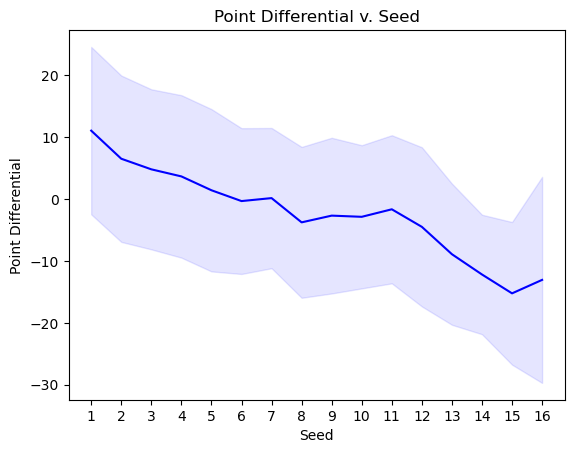

In [16]:
# Visualize how good of a metric seed is for predicting outcome
mu_seed = M_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed =  M_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed - sigma_seed)['PointDiff'])
top = list((mu_seed + sigma_seed)['PointDiff'])

plt.plot(mu_seed.index, mu_seed, 'b-')
plt.fill_between(mu_seed.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed')
plt.ylabel('Point Differential')
plt.xticks(list(range(1,17)))
plt.title("Point Differential v. Seed")

Text(0.5, 1.0, 'Point Differential v. Seed Differential')

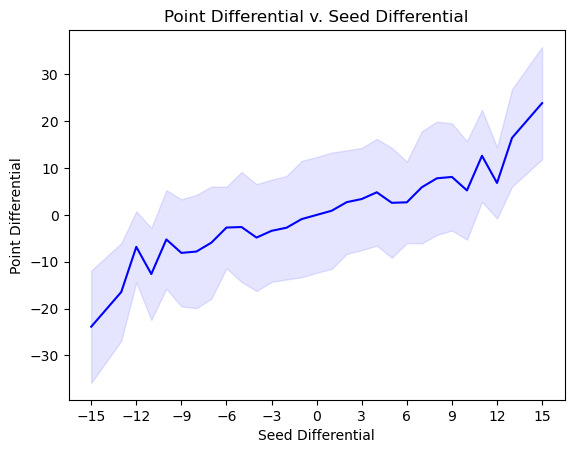

In [17]:
# Visualize how good of a metrics seed differential is for predicting outcome
mu_seed_diff = M_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed_diff =  M_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

plt.plot(mu_seed_diff.index, mu_seed_diff, 'b-')
plt.fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed Differential')
plt.ylabel('Point Differential')
plt.xticks(list(range(-15,16,3)))
plt.title("Point Differential v. Seed Differential")

In [18]:
def pagerank(M, d: float = 0.85):
    """PageRank Algorithm that treats teams as nodes, and outcome in their games as a link
    If Team a loses to Team b >= 1 time during the regular season, 
        This is an event where we demarcate power flow from Team a to Team b
        For Team A, we consider all its losses during the season
            For multiple losses against same team, take average point differential to aggregate
            Compute sum of all margins of loss and normalize each differential with that sum
            Set its column vector based on those calculations
                Team A loses to Team B by avg of 7.5 pts p game during regular season:
                    Entry at column A, Row B of 7.5 / total differential across all losses 
                    (accounting for normalization for losses to same team)
    
    Use the Power Calculation, applying fundamentals of linear algebra

    Parameters
    ----------
    M : numpy array
        adjacency matrix where M_i,j represents the link from 'j' to 'i', such that for all 'j'
        sum(i, M_i,j) = 1

    d : float, optional
        damping factor

    Returns
    -------
    numpy array
        a vector of ranks such that v_i is the i-th rank score (takes on values from  [0, 1]),
        the sum of the values in this array is 1.0

    """
    N = M.shape[1]
    w = np.ones(N) / N
    M_hat = d * M
    v = M_hat @ w + (1 - d) / N
    while np.linalg.norm(w - v) >= 1e-20:
        w = v
        v = M_hat @ w + (1 - d) / N
    return v

In [19]:
# helper function to get key attributes needed for PageRank Function: Winning Team, Losing Team, and their scores
def get_pagerank_info(year):
    return M_regular_season_results[M_regular_season_results["Season"] == year][["WTeamID", "WScore", "LTeamID", "LScore"]]

# list of years to process through
years = list(range(2003, 2026))
years.remove(2020)

# create an empty tample for storing PageRank information
M_pagerank = pd.DataFrame()

# for each year in the years list
for year_idx in tqdm(range(len(years))):

    # get the current year
    year = years[year_idx]

    # make a list of every team that played a game that year
    distinct_team_ids = []
    winner_id_list = get_pagerank_info(year)["WTeamID"].tolist()
    loser_id_list = get_pagerank_info(year)["LTeamID"].tolist()
    id_list = list(set(winner_id_list + loser_id_list))

    # make a helper map from TeamID to position in the distinct_team_id list
    idx_map = dict()
    for i in range(len(id_list)):
        idx_map[id_list[i]] = i

    # create an N x N matrix representing the flow of power in the PageRank Matrix
    N = len(id_list)
    M = np.zeros((N, N))

    # for each team in ID list, prepare a column representing its PageRank Vector
    for curr_team in id_list:

        # get that teams games for that year
        df = get_pagerank_info(year)

        # only factor in losses for each team, since that represents flow of power away from that team (what is stored in that column)
        loss_res = df[df["LTeamID"] == curr_team]

        # compute how much that team lost by and determine opponent team
        loss_res["Diff"] = loss_res["WScore"] - loss_res["LScore"]
        loss_res["Opp_Team"] = loss_res["WTeamID"]
        loss_res['Curr_Team'] = curr_team
        loss_res = loss_res.reset_index()

        # if a team lost to the same team multiple times, average the point differntial and drop the duplicate rows
        loss_res['Avg_Diff'] = loss_res.groupby(['Curr_Team', 'Opp_Team'])['Diff'].transform('mean')
        loss_res = loss_res.drop_duplicates(['Curr_Team', 'Opp_Team'])

        # determine the total point differential lost by across all losses this team had
        total_loss_diff = loss_res['Avg_Diff'].sum()

        # normalize the outgoing column vector based on that total point differential 
        loss_res['Norm_Diff'] = loss_res['Avg_Diff'] / total_loss_diff

        # only keep relevant rows
        loss_res = loss_res[['Curr_Team', 'Opp_Team', 'Norm_Diff']]

        # fill the appropriate positions in the matrix based on the team lost to and the power that flows to that team
        for index, row in loss_res.iterrows():
            c = idx_map[curr_team]
            r = idx_map[int(row['Opp_Team'])]
            M[r, c] += row['Norm_Diff']

    # compute a pagerank vector based on the matrix, and a damping factor parameter, experimentally chosen to be 0.1
    v = pagerank(M, 0.1) # between 0 and 1

    # create a list of tuples (i: position in id_list, x: strength as computed by pagerank)
    idx_power_list = []

    for i, x in enumerate(v):
        idx_power_list.append((i,x))

    # order the list by strongest to weakest teams
    idx_power_list.sort(key = lambda x: x[1], reverse = True)

    # append the results to the dataframe
    M_pagerank_year = pd.DataFrame({'PR_Power' : [x[1] for x in idx_power_list], 'TeamID' : [id_list[x[0]] for x in idx_power_list]})
    M_pagerank_year['Season'] = year

    M_pagerank = pd.concat([M_pagerank, M_pagerank_year])

100%|██████████| 22/22 [00:19<00:00,  1.11it/s]


In [20]:
M_pagerank

,PR_Power,TeamID,Season
0,0.003915,1257,2003
1,0.003775,1242,2003
2,0.003774,1338,2003
3,0.003770,1246,2003
4,0.003733,1181,2003
...,...,...,...
359,0.002495,1115,2025
360,0.002494,1170,2025
361,0.002494,1271,2025
362,0.002488,1154,2025


In [21]:
T1_PR = M_pagerank[["Season", "TeamID", "PR_Power"]].copy()
T2_PR = M_pagerank[["Season", "TeamID", "PR_Power"]].copy()

T1_PR.columns = ["Season", "T1_TeamID", "T1_PageRank"]
T2_PR.columns = ["Season", "T2_TeamID", "T2_PageRank"]

M_tourney_data_slice = M_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

M_tourney_data_slice = pd.merge(M_tourney_data_slice, T1_PR, on=["Season", "T1_TeamID"], how = "left")
M_tourney_data_slice = pd.merge(M_tourney_data_slice, T2_PR, on=["Season", "T2_TeamID"], how = "left")

M_tourney_data_slice["PageRank_Diff"] = M_tourney_data_slice["T2_PageRank"] - M_tourney_data_slice["T1_PageRank"]
M_tourney_data = pd.merge(M_tourney_data, M_tourney_data_slice, on = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"], how = "left")
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff
0,2003,1421,1411,7.111111,1,16,16,0,0.002888,0.002940,0.000052
1,2003,1112,1436,29.000000,1,1,16,15,0.003689,0.003029,-0.000660
2,2003,1113,1272,13.000000,1,10,7,-3,0.003340,0.003383,0.000042
3,2003,1141,1166,6.000000,1,11,6,-5,0.003151,0.003643,0.000492
4,2003,1143,1301,1.777778,1,8,9,1,0.003168,0.003254,0.000086
...,...,...,...,...,...,...,...,...,...,...,...
2893,2025,1277,1120,-6.000000,0,2,1,-1,0.003191,0.003654,0.000463
2894,2025,1397,1222,-19.000000,0,2,1,-1,0.003585,0.003387,-0.000198
2895,2025,1120,1196,-6.000000,0,1,1,0,0.003654,0.003794,0.000140
2896,2025,1181,1222,-3.000000,0,1,1,0,0.003744,0.003387,-0.000356


In [22]:
# dataframe to store most correlated features with point differential
correlation_df = pd.DataFrame(columns=["Stat", "r", "r_diff"])
correlation_df

,Stat,r,r_diff


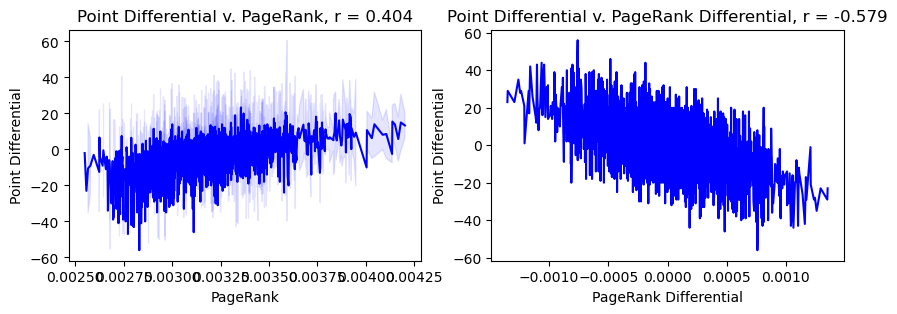

       Stat         r    r_diff
0  PageRank  0.403613 -0.578638


In [23]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation(stat_name, start_year = 2003):

    # Visualize how good of a metric the raw stat is for predicting outcome

    subset_tourney_data = M_tourney_data.loc[M_tourney_data["Season"] >= start_year].copy()

    corr_df = subset_tourney_data[["PointDiff", f"T1_{stat_name}"]].copy()
    r = corr_df.corr().iloc[0,1]

    mu_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_stat - sigma_stat)['PointDiff'])
    top = list((mu_stat + sigma_stat)['PointDiff'])

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(3)
    fig.set_figwidth(10)

    condensed_stat_name = stat_name if not "opponent" in stat_name else stat_name[:7] + stat_name[12:]

    axs[0].plot(mu_stat.index, mu_stat, 'b-')
    axs[0].fill_between(mu_stat.index,bottom, top, color="b", alpha=0.1)
    axs[0].set_xlabel(condensed_stat_name)
    axs[0].set_ylabel('Point Differential')
    axs[0].set_title(f"Point Differential v. {condensed_stat_name}, r = {r:.3f}")

    # Visualize how good of a metrics stat differential is for predicting outcome

    subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

    corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
    r_diff = corr_diff_df.corr().iloc[0,1]

    mu_seed_diff = subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_seed_diff =  subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
    top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

    axs[1].plot(mu_seed_diff.index, mu_seed_diff, 'b-')
    axs[1].fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
    axs[1].set_xlabel(f'{condensed_stat_name} Differential')
    axs[1].set_ylabel('Point Differential')
    axs[1].set_title(f"Point Differential v. {condensed_stat_name} Differential, r = {r_diff:.3f}")

    # adding to global correlation df
    correlation_df.loc[len(correlation_df)] = [condensed_stat_name, r, r_diff]
    plt.show()

visualize_stat_correlation("PageRank")
print(correlation_df)

In [24]:
# only examine ranking systems that were updated the day before the tournament started
M_ranks = M_ranks[M_ranks['RankingDayNum'] == 133]
systems = list(set(M_ranks['SystemName'].tolist()))

systems


['PKL',
 'KBM',
 'BAR',
 'LAB',
 'ADE',
 'HAS',
 'RT',
 'TBD',
 'RIS',
 'RTR',
 'JEN',
 'NET',
 'SAP',
 'WOL',
 'JRT',
 'ROG',
 'RMS',
 'HOL',
 'INC',
 'EMK',
 'STH',
 'CWL',
 'HKS',
 'CMV',
 'IMS',
 'BMN',
 'ZAM',
 'SCR',
 'DP',
 'PH',
 'BCM',
 'OCT',
 'HRN',
 'JON',
 'OMY',
 'DDB',
 'STM',
 'TW',
 'BWE',
 'OMN',
 'DII',
 'STY',
 'PIG',
 'JNG',
 'BNT',
 'SMS',
 'WLK',
 'BKM',
 'RM',
 'SIM',
 'COX',
 'PTS',
 'TRP',
 'AUS',
 'LOG',
 'SE',
 'SAG',
 'SRS',
 'SAU',
 'ATP',
 'SEL',
 'RTB',
 'BD',
 'STF',
 'TRX',
 'MvG',
 'STS',
 'FSH',
 'SMN',
 'DOL',
 '7OT',
 'FAS',
 'ARG',
 'BPI',
 'TMR',
 'JJK',
 'NOL',
 'HKB',
 'TPR',
 'RTH',
 'RTP',
 'LYD',
 'WLS',
 'INP',
 'CBR',
 'LYN',
 'GRS',
 'DWH',
 'LEF',
 'PAC',
 'ISR',
 'PGH',
 'BNZ',
 'SGR',
 'DOK',
 'PIR',
 'BNM',
 'KMV',
 'WMR',
 'ENG',
 'MMG',
 'MAS',
 'MGY',
 'MOR',
 'WEI',
 'KEL',
 'CPR',
 'ACU',
 'SP',
 'TSR',
 'WAB',
 'BOB',
 'JCI',
 'RSE',
 'SFX',
 'UPS',
 'KCX',
 'DES',
 'ROH',
 'PMC',
 'LAW',
 'DC2',
 'MGS',
 'REI',
 'MUZ',
 'MKV',


In [25]:
# playing around with the data to see which systems are still active and worthwhile
system = systems[0]

print(system)

sys_ranks = M_ranks[M_ranks['SystemName'] == system]

T1_sys = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()

active_systems = []

for i in tqdm(range(len(systems))):
    system = systems[i]
    sys_ranks = M_ranks[M_ranks['SystemName'] == system]
    T1_sys = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()

    if list(set(T1_sys["Season"].tolist()))[-1] >= 2025:
        print(system, list(set(T1_sys["Season"].tolist())))
        active_systems.append(system)

print(active_systems)

PKL


  5%|▌         | 10/184 [00:00<00:06, 27.82it/s]

HAS [2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
NET [2019, 2021, 2022, 2023, 2024, 2025]


 11%|█▏        | 21/184 [00:00<00:03, 42.56it/s]

WOL [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2025]
INC [2019, 2021, 2022, 2023, 2024, 2025]
EMK [2021, 2022, 2023, 2024, 2025]


...

ESR [2017, 2018, 2019, 2022, 2023, 2024, 2025]
RPI [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2023, 2024, 2025, 2026]
WIL [2005, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]
AP [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]


 90%|████████▉ | 165/184 [00:03<00:00, 56.96it/s]

BIH [2003, 2004, 2005, 2006, 2007, 2008, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]
KPI [2016, 2017, 2018, 2019, 2024, 2025]
POM [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025, 2026]


100%|██████████| 184/184 [00:03<00:00, 52.93it/s]

USA [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
COL [2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024, 2025]
['HAS', 'NET', 'WOL', 'INC', 'EMK', 'BMN', 'DP', 'JNG', 'SMS', 'WLK', 'SRS', 'DOL', 'FAS', 'JJK', 'RTH', 'WLS', 'PAC', 'BNZ', 'DOK', 'PIR', 'ENG', 'MMG', 'MAS', 'MOR', 'WEI', 'WAB', 'ESR', 'RPI', 'WIL', 'AP', 'BIH', 'KPI', 'POM', 'USA', 'COL']


In [26]:
# viewiing tournament dataframe
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff
0,2003,1421,1411,7.111111,1,16,16,0,0.002888,0.002940,0.000052
1,2003,1112,1436,29.000000,1,1,16,15,0.003689,0.003029,-0.000660
2,2003,1113,1272,13.000000,1,10,7,-3,0.003340,0.003383,0.000042
3,2003,1141,1166,6.000000,1,11,6,-5,0.003151,0.003643,0.000492
4,2003,1143,1301,1.777778,1,8,9,1,0.003168,0.003254,0.000086
...,...,...,...,...,...,...,...,...,...,...,...
2893,2025,1277,1120,-6.000000,0,2,1,-1,0.003191,0.003654,0.000463
2894,2025,1397,1222,-19.000000,0,2,1,-1,0.003585,0.003387,-0.000198
2895,2025,1120,1196,-6.000000,0,1,1,0,0.003654,0.003794,0.000140
2896,2025,1181,1222,-3.000000,0,1,1,0,0.003744,0.003387,-0.000356


NET


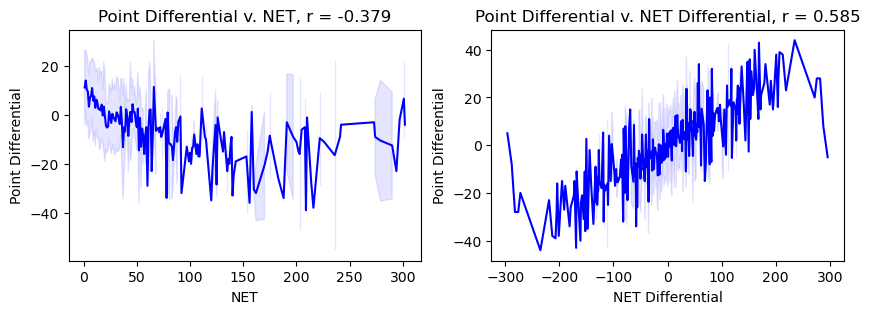

BIH


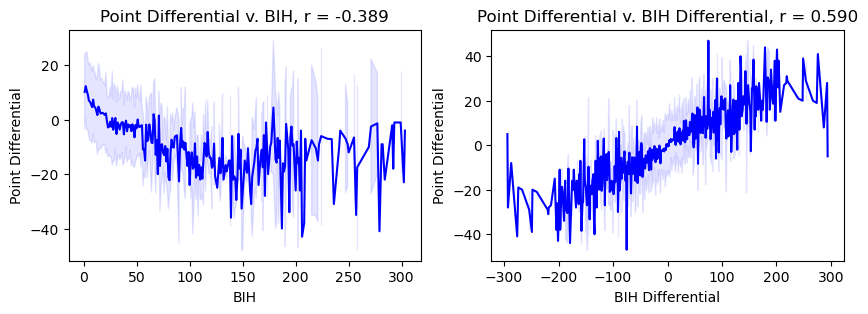

DP


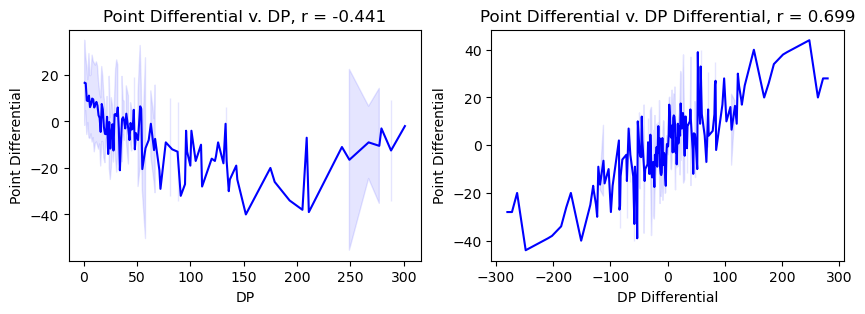

INC


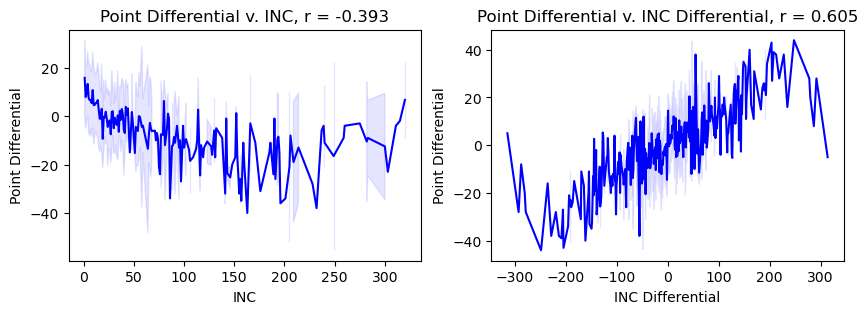

ESR


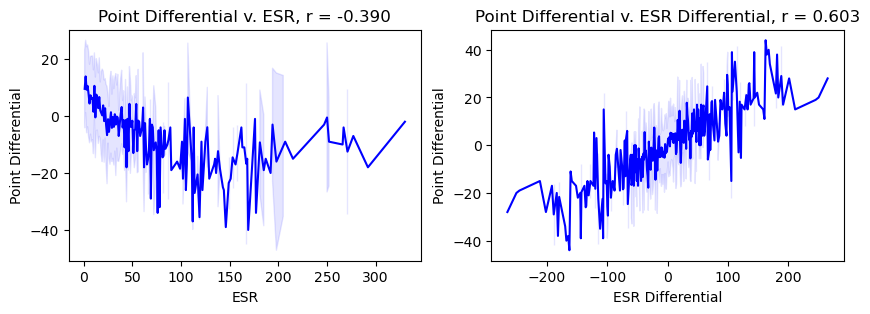

MMG


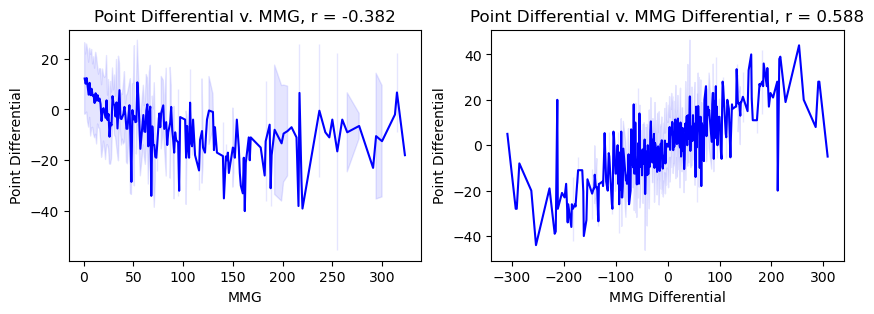

JJK


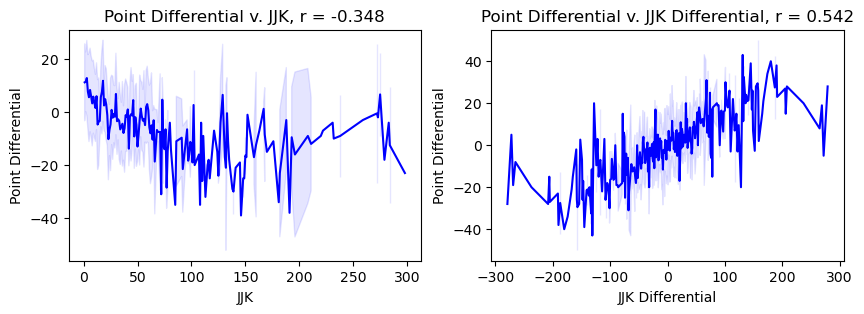

BNZ


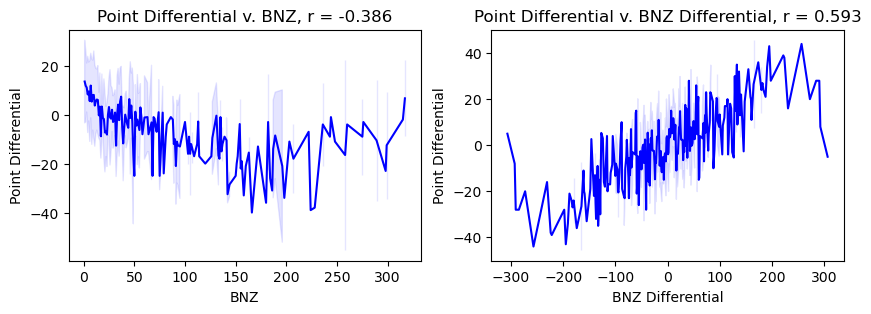

RPI


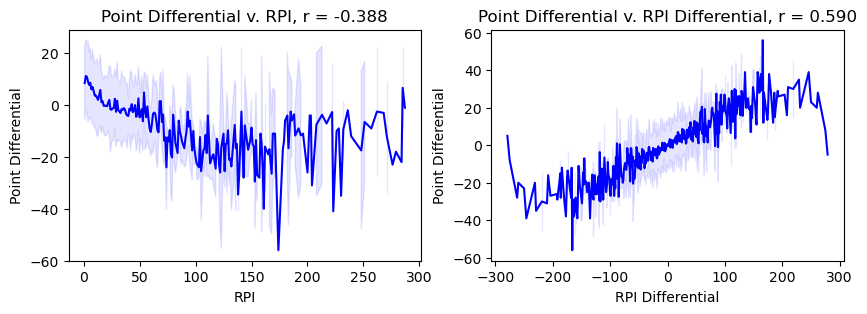

WAB


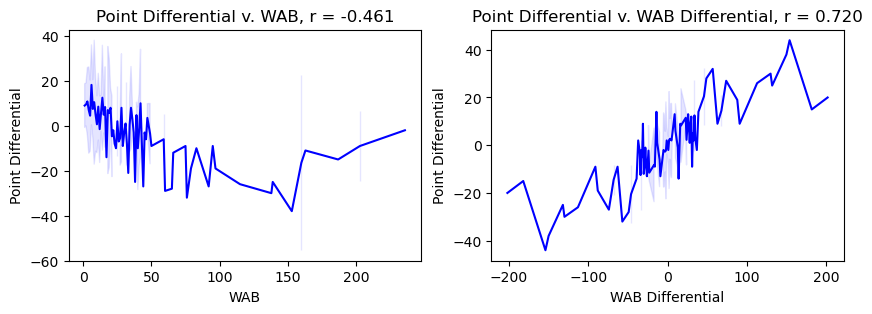

MAS


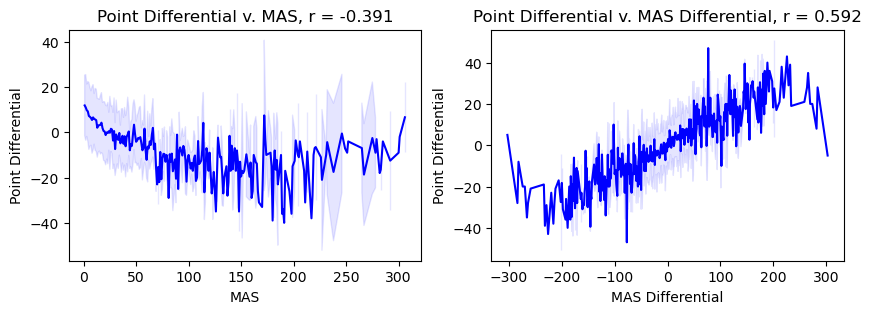

AP


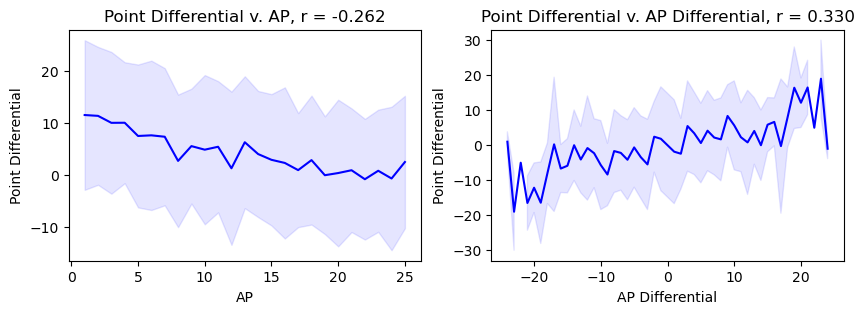

SRS


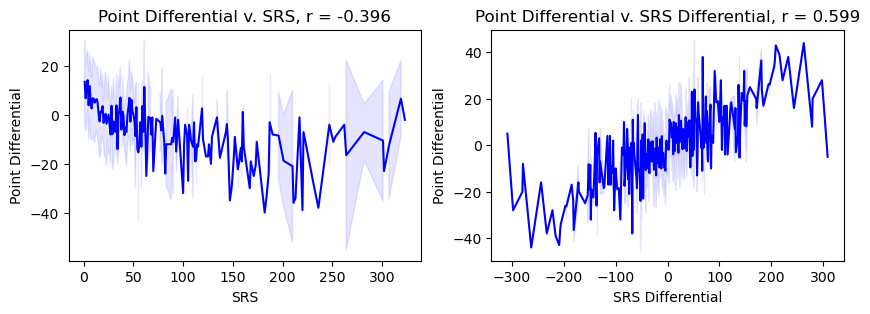

PIR


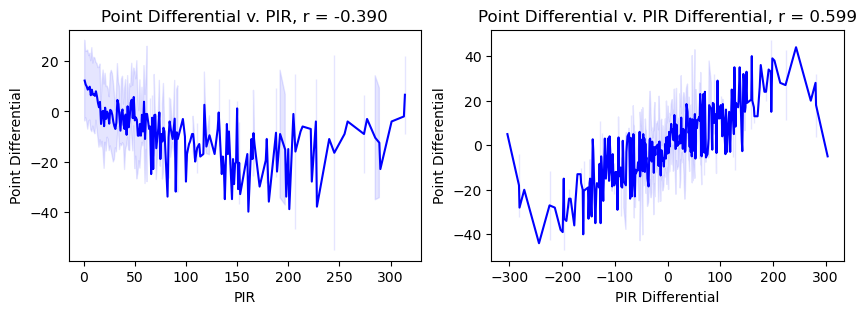

DOL


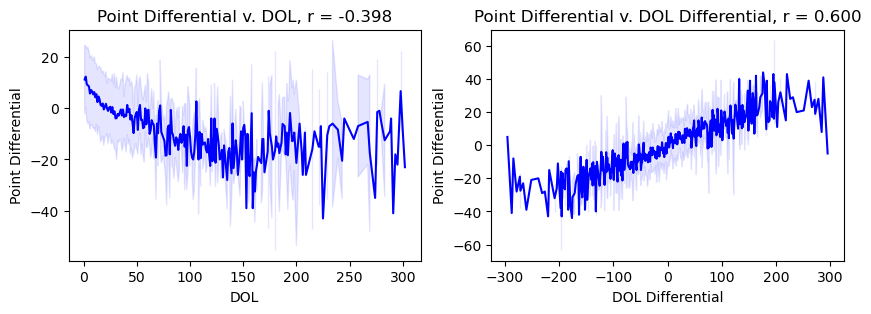

PAC


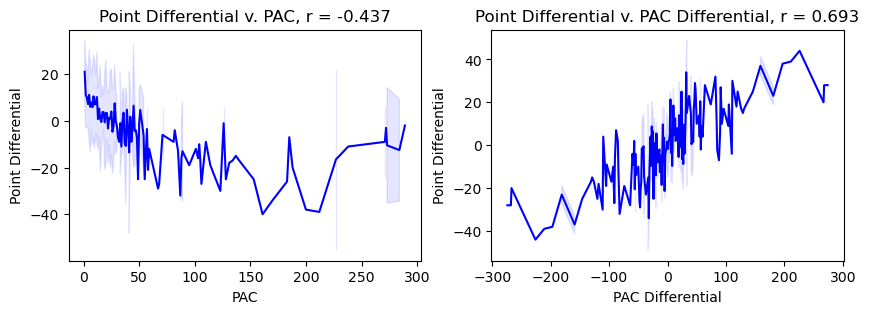

POM


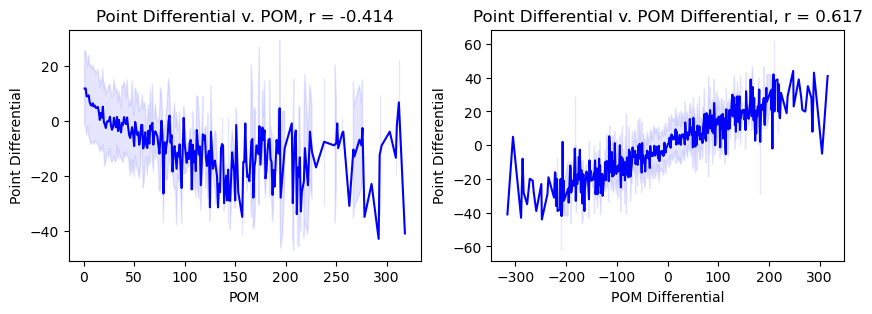

EMK


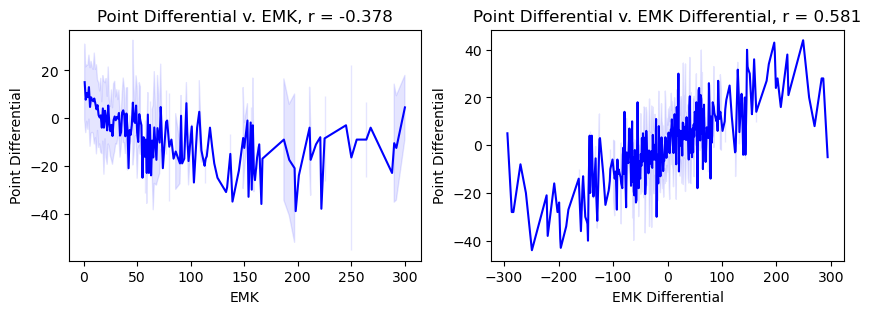

DOK


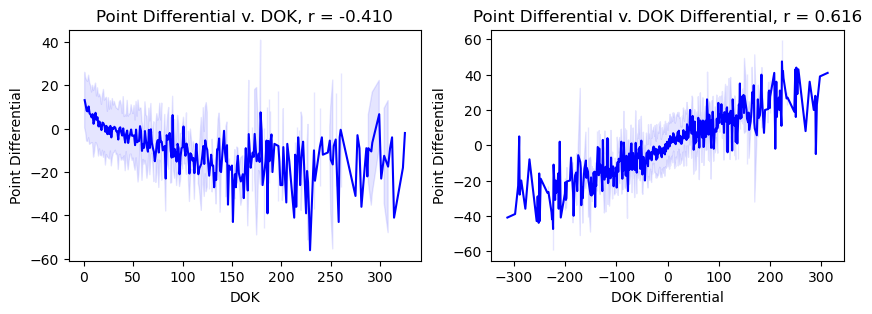

MOR


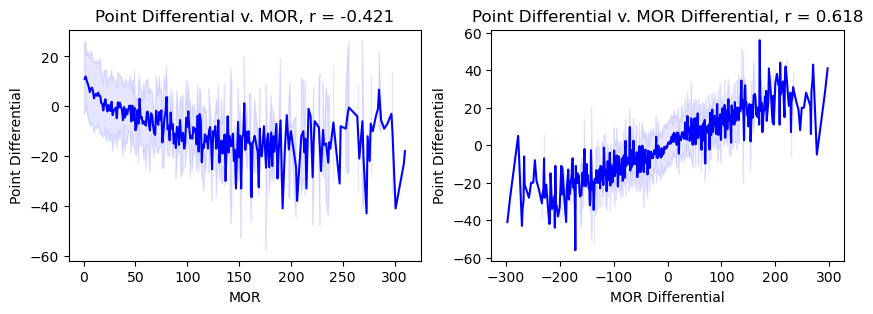

RTH


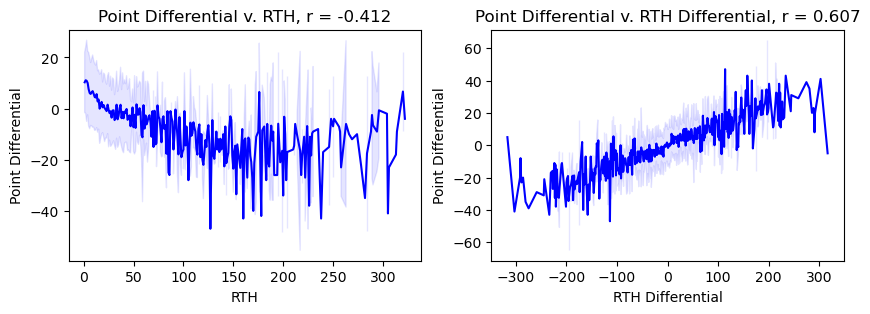

FAS


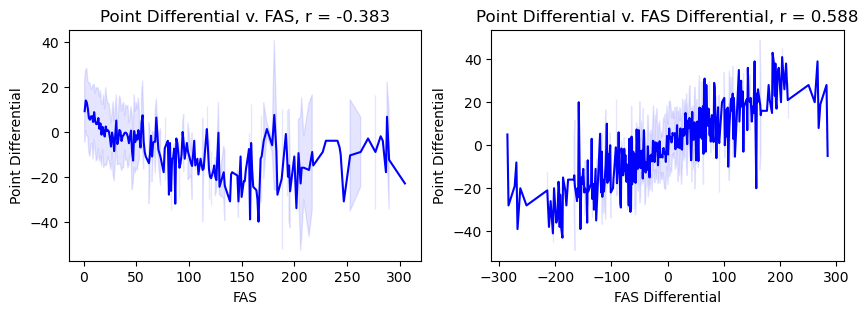

WOL


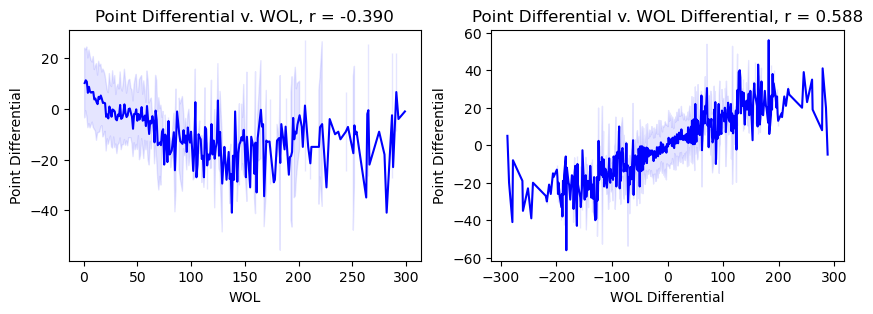

WLK


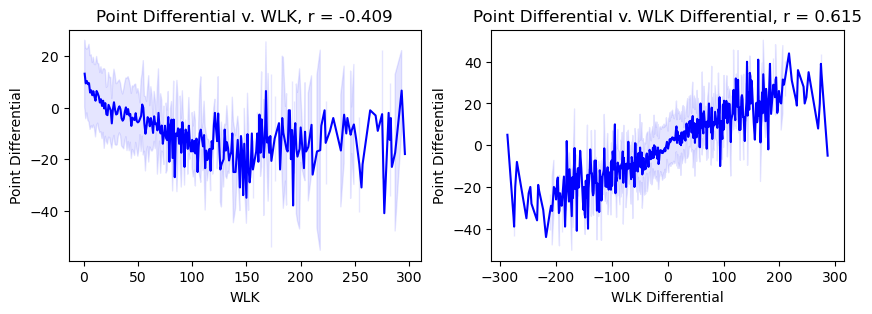

KPI


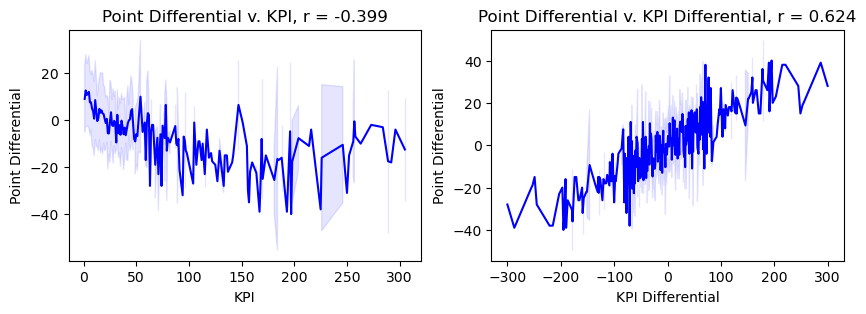

COL


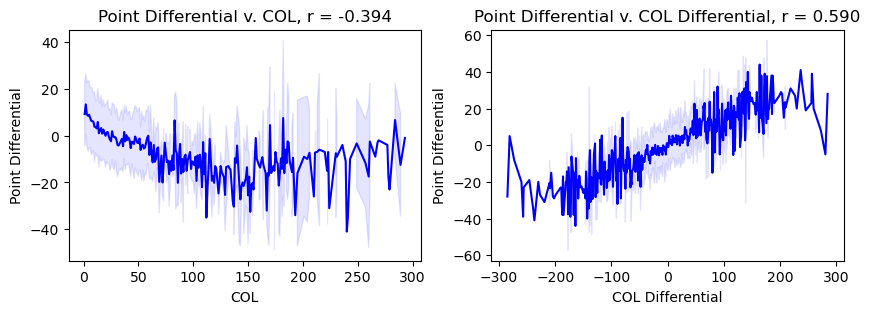

BMN


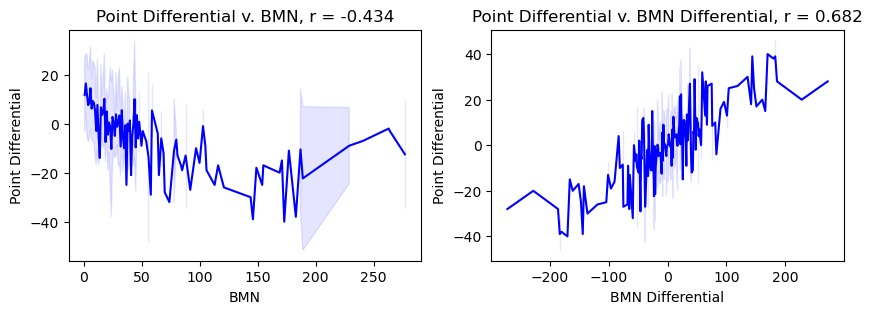

HAS


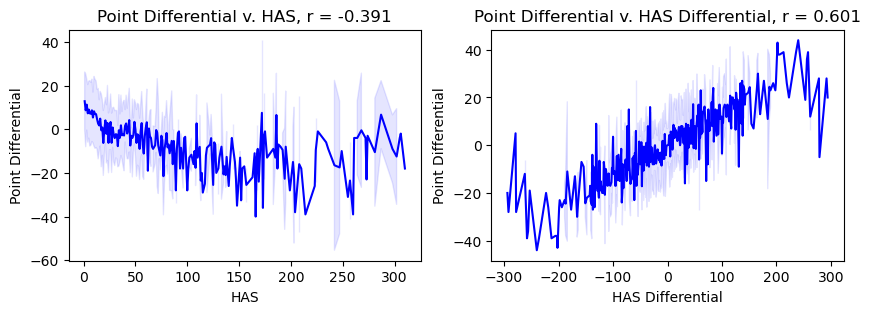

WIL


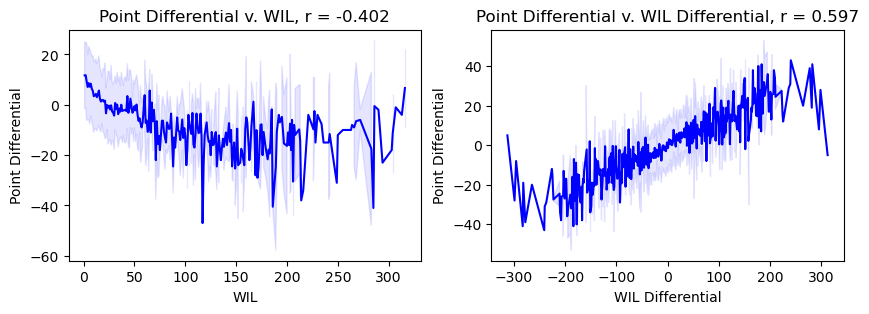

JNG


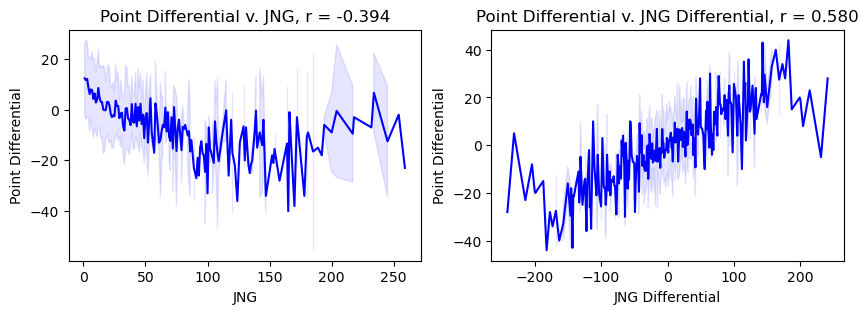

SMS


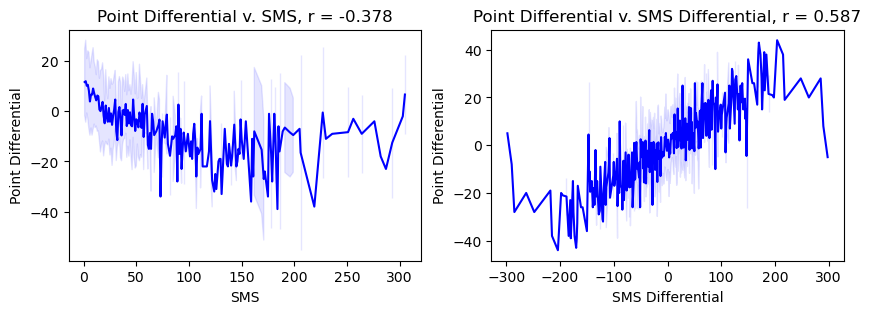

USA


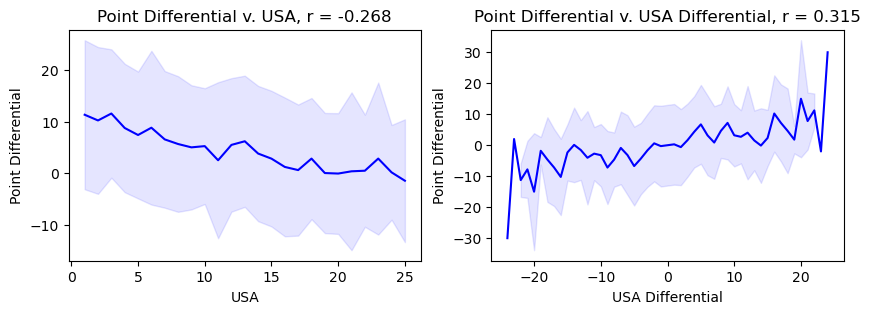

In [27]:
# determine ranking systems we are interested in viewing statistics of
active_systems = ['NET', 'BIH', 'DP', 'INC', 'ESR', 'MMG', 'JJK', 'BNZ', 'RPI', 'WAB', 'MAS', 'AP', 'SRS', 'PIR', 'DOL', 'PAC', 'POM', 'EMK', 'DOK', 'MOR', 'RTH', 'FAS', 'WOL', 'WLK', 'KPI', 'COL', 'BMN', 'HAS', 'WIL', 'JNG', 'SMS', 'USA']

# for each of the chosen ranking systems, add to dataframe and visualize their correlation with point differential
for ac_sys in active_systems:

    sys_ranks = M_ranks[M_ranks['SystemName'] == ac_sys]


    rank_str = ac_sys

    print(rank_str)

    T1_system = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()
    T2_system = sys_ranks[["Season", "TeamID", "OrdinalRank"]].copy()

    T1_system.columns = ["Season", "T1_TeamID", f"T1_{rank_str}"]
    T2_system.columns = ["Season", "T2_TeamID", f"T2_{rank_str}"]

    M_tourney_data_slice = M_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

    M_tourney_data_slice = pd.merge(M_tourney_data_slice, T1_system, on=["Season", "T1_TeamID"], how = "left")
    M_tourney_data_slice = pd.merge(M_tourney_data_slice, T2_system, on=["Season", "T2_TeamID"], how = "left")

    M_tourney_data_slice[f"{rank_str}_Diff"] = M_tourney_data_slice[f"T2_{rank_str}"] - M_tourney_data_slice[f"T1_{rank_str}"]
    M_tourney_data = pd.merge(M_tourney_data, M_tourney_data_slice, on = ["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"], how = "left")

    visualize_stat_correlation(ac_sys)

In [28]:
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff,T1_NET,T2_NET,NET_Diff,T1_BIH,T2_BIH,BIH_Diff,T1_DP,T2_DP,DP_Diff,T1_INC,T2_INC,INC_Diff,T1_ESR,T2_ESR,ESR_Diff,T1_MMG,T2_MMG,MMG_Diff,T1_JJK,T2_JJK,JJK_Diff,T1_BNZ,T2_BNZ,BNZ_Diff,T1_RPI,T2_RPI,RPI_Diff,T1_WAB,T2_WAB,WAB_Diff,T1_MAS,T2_MAS,MAS_Diff,T1_AP,T2_AP,AP_Diff,T1_SRS,T2_SRS,SRS_Diff,T1_PIR,T2_PIR,PIR_Diff,T1_DOL,T2_DOL,DOL_Diff,T1_PAC,T2_PAC,PAC_Diff,T1_POM,T2_POM,POM_Diff,T1_EMK,T2_EMK,EMK_Diff,T1_DOK,T2_DOK,DOK_Diff,T1_MOR,T2_MOR,MOR_Diff,T1_RTH,T2_RTH,RTH_Diff,T1_FAS,T2_FAS,FAS_Diff,T1_WOL,T2_WOL,WOL_Diff,T1_WLK,T2_WLK,WLK_Diff,T1_KPI,T2_KPI,KPI_Diff,T1_COL,T2_COL,COL_Diff,T1_BMN,T2_BMN,BMN_Diff,T1_HAS,T2_HAS,HAS_Diff,T1_WIL,T2_WIL,WIL_Diff,T1_JNG,T2_JNG,JNG_Diff,T1_SMS,T2_SMS,SMS_Diff,T1_USA,T2_USA,USA_Diff
0,2003,1421,1411,7.111111,1,16,16,0,0.002888,0.002940,0.000052,NaN,NaN,NaN,247.0,234.0,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186.0,217.0,31.0,NaN,NaN,NaN,265.0,249.0,-16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,239,-19,NaN,NaN,NaN,273,268,-5,NaN,NaN,NaN,NaN,NaN,NaN,277,293,16,250.0,256.0,6.0,NaN,NaN,NaN,220.0,246.0,26.0,237,240,3,NaN,NaN,NaN,213,212,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2003,1112,1436,29.000000,1,1,16,15,0.003689,0.003029,-0.000660,NaN,NaN,NaN,2.0,151.0,149.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,144.0,142.0,NaN,NaN,NaN,3.0,148.0,145.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,156,154,NaN,NaN,NaN,3,144,141,NaN,NaN,NaN,NaN,NaN,NaN,4,187,183,2.0,182.0,180.0,NaN,NaN,NaN,2.0,177.0,175.0,2,153,151,NaN,NaN,NaN,2,144,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,2003,1113,1272,13.000000,1,10,7,-3,0.003340,0.003383,0.000042,NaN,NaN,NaN,43.0,19.0,-24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,26.0,-6.0,NaN,NaN,NaN,40.0,18.0,-22.0,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,21,-27,NaN,NaN,NaN,32,20,-12,NaN,NaN,NaN,NaN,NaN,NaN,22,23,1,35.0,19.0,-16.0,NaN,NaN,NaN,39.0,19.0,-20.0,34,21,-13,NaN,NaN,NaN,38,19,-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0,NaN
3,2003,1141,1166,6.000000,1,11,6,-5,0.003151,0.003643,0.000492,NaN,NaN,NaN,38.0,17.0,-21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.0,23.0,-21.0,NaN,NaN,NaN,36.0,19.0,-17.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37,18,-19,NaN,NaN,NaN,50,27,-23,NaN,NaN,NaN,NaN,NaN,NaN,50,33,-17,55.0,22.0,-33.0,NaN,NaN,NaN,49.0,17.0,-32.0,32,19,-13,NaN,NaN,NaN,35,18,-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN
4,2003,1143,1301,1.777778,1,8,9,1,0.003168,0.003254,0.000086,NaN,NaN,NaN,26.0,49.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,53.0,20.0,NaN,NaN,NaN,30.0,48.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,49,24,NaN,NaN,NaN,40,48,8,NaN,NaN,NaN,NaN,NaN,NaN,43,31,-12,30.0,42.0,12.0,NaN,NaN,NaN,26.0,47.0,21.0,33,51,18,NaN,NaN,NaN,28,56,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2893,2025,1277,1120,-6.000000,0,2,1,-1,0.003191,0.003654,0.000463,11.0,2.0,-9.0,7.0,1.0,-6.0,9.0,4.0,-5.0,7.0,3.0,-4.0,8.0,1.0,-7.0,12.0,3.0,-9.0,8.0,1.0,-7.0,12.0,2.0,-10.0,7.0,1.0,-6.0,7.0,1.0,-6.0,8.0,4.0,-4.0,8.0,4.0,-4.0,12.0,2.0,-10.0,10.0,2.0,-8.0,8,1,-7,7.0,4.0,-3.0,8,4,-4,11.0,4.0,-7.0,10.0,3.0,-7.0,8,4,-4,7.0,2.0,-5.0,7.0,1.0,-6.0,7.0,2.0,-5.0,7,2,-5,7.0,1.0,-6.0,7,1,-6,7.0,1.0,-6.0,11.0,4.0,-7.0,7.0,1.0,-6.0,6.0,1.0,-5.0,7.0,1.0,

In [29]:
# list which stats we want to aggregate acros the season for each team 
#   - calculate all interesting features
box_score_stats = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff"
]

In [30]:
# aggregate the average statistics for every team across the season and concatenate the corresponding
# columns on the tournament matchup data
season_stats = M_reg_data.groupby(["Season", "T1_TeamID"])[box_score_stats].agg("mean").reset_index()

season_stats_T1 = season_stats.copy()
season_stats_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T1.columns)]
season_stats_T1 = season_stats_T1.rename({"T1_avg_Season" : "Season", "T1_avg_TeamID" : "T1_TeamID"}, axis = 1)

season_stats_T2 = season_stats.copy()
season_stats_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T2.columns)]
season_stats_T2 = season_stats_T2.rename({"T2_avg_Season" : "Season", "T2_avg_TeamID" : "T2_TeamID"}, axis = 1)

M_tourney_data = pd.merge(M_tourney_data, season_stats_T1, on = ["Season", "T1_TeamID"], how = "left")
M_tourney_data = pd.merge(M_tourney_data, season_stats_T2, on = ["Season", "T2_TeamID"], how = "left")
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff,T1_NET,T2_NET,NET_Diff,T1_BIH,T2_BIH,BIH_Diff,T1_DP,T2_DP,DP_Diff,T1_INC,T2_INC,INC_Diff,T1_ESR,T2_ESR,ESR_Diff,T1_MMG,T2_MMG,MMG_Diff,T1_JJK,T2_JJK,JJK_Diff,T1_BNZ,T2_BNZ,BNZ_Diff,T1_RPI,T2_RPI,RPI_Diff,T1_WAB,T2_WAB,WAB_Diff,T1_MAS,T2_MAS,MAS_Diff,T1_AP,T2_AP,AP_Diff,T1_SRS,T2_SRS,SRS_Diff,T1_PIR,T2_PIR,PIR_Diff,T1_DOL,T2_DOL,DOL_Diff,T1_PAC,T2_PAC,PAC_Diff,T1_POM,T2_POM,POM_Diff,T1_EMK,T2_EMK,EMK_Diff,T1_DOK,T2_DOK,DOK_Diff,T1_MOR,T2_MOR,MOR_Diff,T1_RTH,T2_RTH,RTH_Diff,T1_FAS,T2_FAS,FAS_Diff,T1_WOL,T2_WOL,WOL_Diff,T1_WLK,T2_WLK,WLK_Diff,T1_KPI,T2_KPI,KPI_Diff,T1_COL,T2_COL,COL_Diff,T1_BMN,T2_BMN,BMN_Diff,T1_HAS,T2_HAS,HAS_Diff,T1_WIL,T2_WIL,WIL_Diff,T1_JNG,T2_JNG,JNG_Diff,T1_SMS,T2_SMS,SMS_Diff,T1_USA,T2_USA,USA_Diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,16,16,0,0.002888,0.002940,0.000052,NaN,NaN,NaN,247.0,234.0,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186.0,217.0,31.0,NaN,NaN,NaN,265.0,249.0,-16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,239,-19,NaN,NaN,NaN,273,268,-5,NaN,NaN,NaN,NaN,NaN,NaN,277,293,16,250.0,256.0,6.0,NaN,NaN,NaN,220.0,246.0,26.0,237,240,3,NaN,NaN,NaN,213,212,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,16,15,0.003689,0.003029,-0.000660,NaN,NaN,NaN,2.0,151.0,149.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,144.0,142.0,NaN,NaN,NaN,3.0,148.0,145.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,156,154,NaN,NaN,NaN,3,144,141,NaN,NaN,NaN,NaN,NaN,NaN,4,187,183,2.0,182.0,180.0,NaN,NaN,NaN,2.0,177.0,175.0,2,153,151,NaN,NaN,NaN,2,144,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,10,7,-3,0.003340,0.003383,0.000042,NaN,NaN,NaN,43.0,19.0,-24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,26.0,-6.0,NaN,NaN,NaN,40.0,18.0,-

In [31]:
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_PageRank,T2_PageRank,PageRank_Diff,T1_NET,T2_NET,NET_Diff,T1_BIH,T2_BIH,BIH_Diff,T1_DP,T2_DP,DP_Diff,T1_INC,T2_INC,INC_Diff,T1_ESR,T2_ESR,ESR_Diff,T1_MMG,T2_MMG,MMG_Diff,T1_JJK,T2_JJK,JJK_Diff,T1_BNZ,T2_BNZ,BNZ_Diff,T1_RPI,T2_RPI,RPI_Diff,T1_WAB,T2_WAB,WAB_Diff,T1_MAS,T2_MAS,MAS_Diff,T1_AP,T2_AP,AP_Diff,T1_SRS,T2_SRS,SRS_Diff,T1_PIR,T2_PIR,PIR_Diff,T1_DOL,T2_DOL,DOL_Diff,T1_PAC,T2_PAC,PAC_Diff,T1_POM,T2_POM,POM_Diff,T1_EMK,T2_EMK,EMK_Diff,T1_DOK,T2_DOK,DOK_Diff,T1_MOR,T2_MOR,MOR_Diff,T1_RTH,T2_RTH,RTH_Diff,T1_FAS,T2_FAS,FAS_Diff,T1_WOL,T2_WOL,WOL_Diff,T1_WLK,T2_WLK,WLK_Diff,T1_KPI,T2_KPI,KPI_Diff,T1_COL,T2_COL,COL_Diff,T1_BMN,T2_BMN,BMN_Diff,T1_HAS,T2_HAS,HAS_Diff,T1_WIL,T2_WIL,WIL_Diff,T1_JNG,T2_JNG,JNG_Diff,T1_SMS,T2_SMS,SMS_Diff,T1_USA,T2_USA,USA_Diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,16,16,0,0.002888,0.002940,0.000052,NaN,NaN,NaN,247.0,234.0,-13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186.0,217.0,31.0,NaN,NaN,NaN,265.0,249.0,-16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,239,-19,NaN,NaN,NaN,273,268,-5,NaN,NaN,NaN,NaN,NaN,NaN,277,293,16,250.0,256.0,6.0,NaN,NaN,NaN,220.0,246.0,26.0,237,240,3,NaN,NaN,NaN,213,212,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,16,15,0.003689,0.003029,-0.000660,NaN,NaN,NaN,2.0,151.0,149.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,144.0,142.0,NaN,NaN,NaN,3.0,148.0,145.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,156,154,NaN,NaN,NaN,3,144,141,NaN,NaN,NaN,NaN,NaN,NaN,4,187,183,2.0,182.0,180.0,NaN,NaN,NaN,2.0,177.0,175.0,2,153,151,NaN,NaN,NaN,2,144,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,10,7,-3,0.003340,0.003383,0.000042,NaN,NaN,NaN,43.0,19.0,-24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,26.0,-6.0,NaN,NaN,NaN,40.0,18.0,-

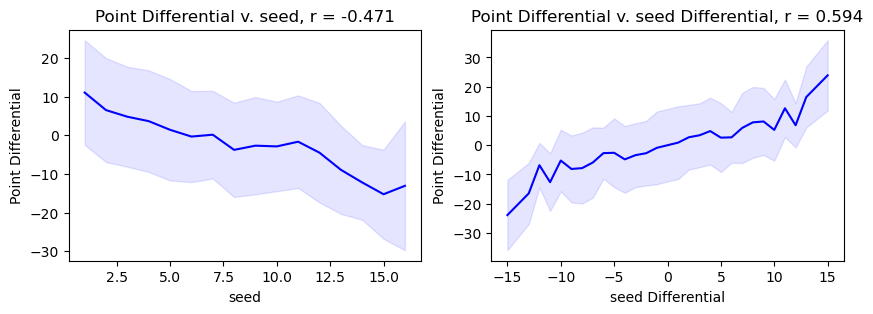

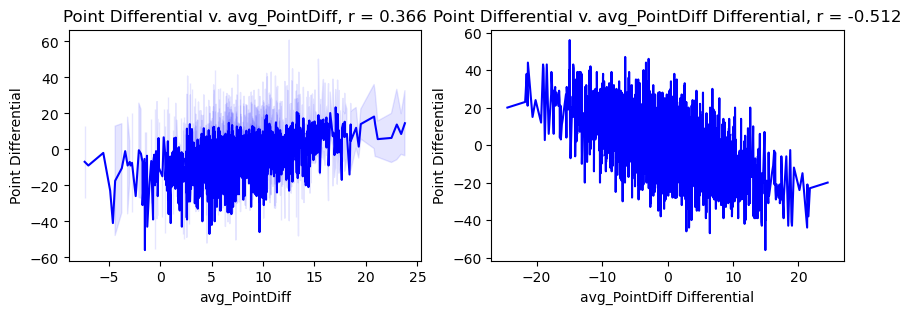

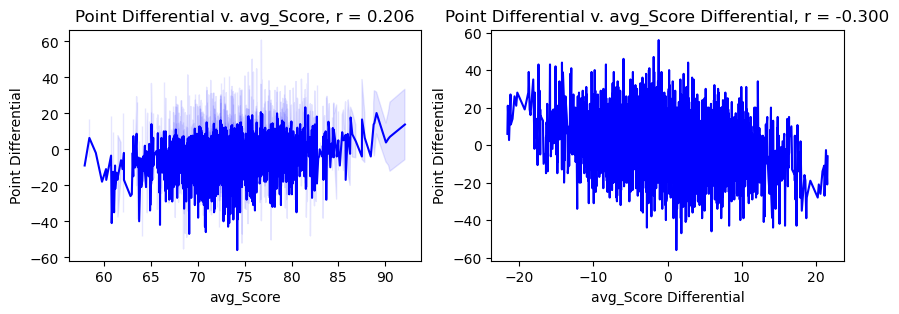

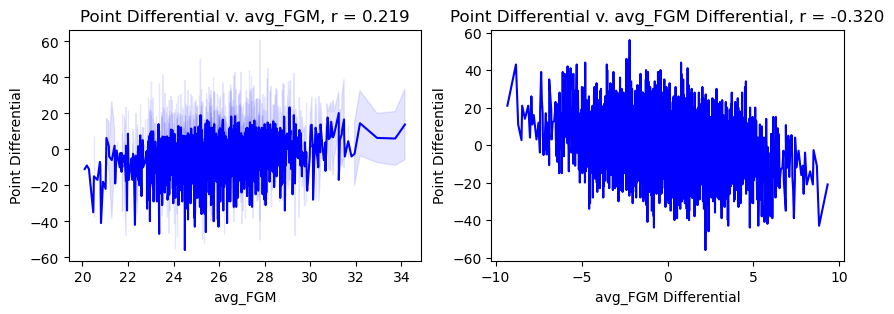

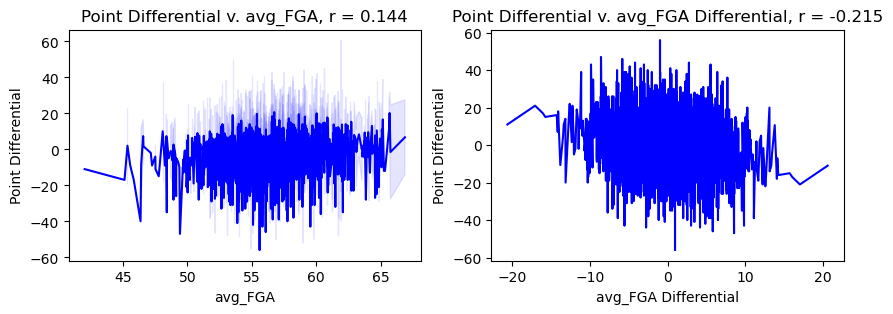

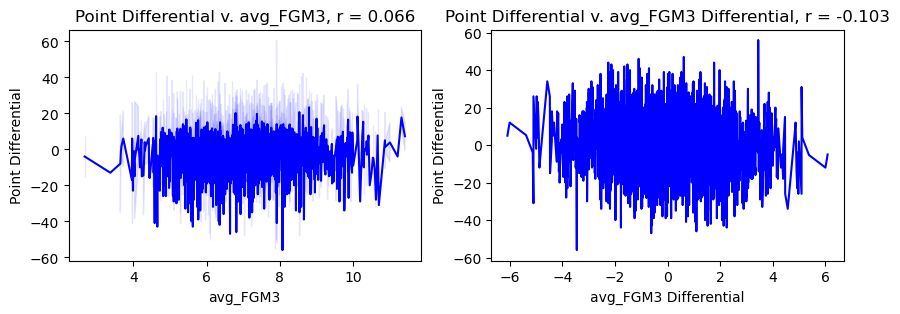

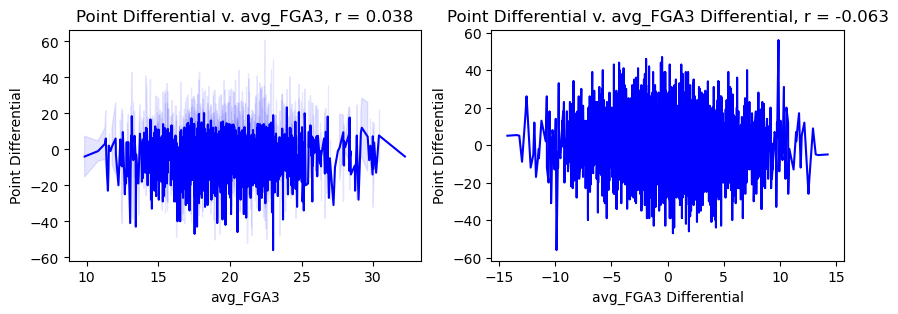

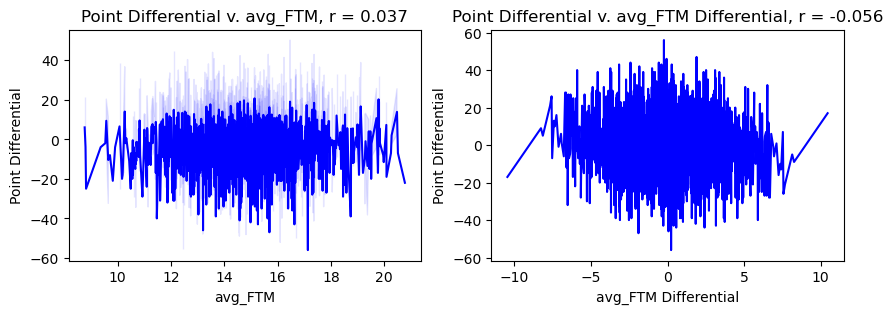

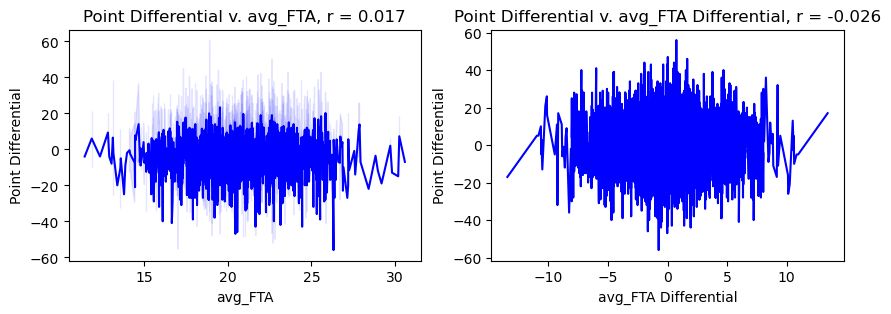

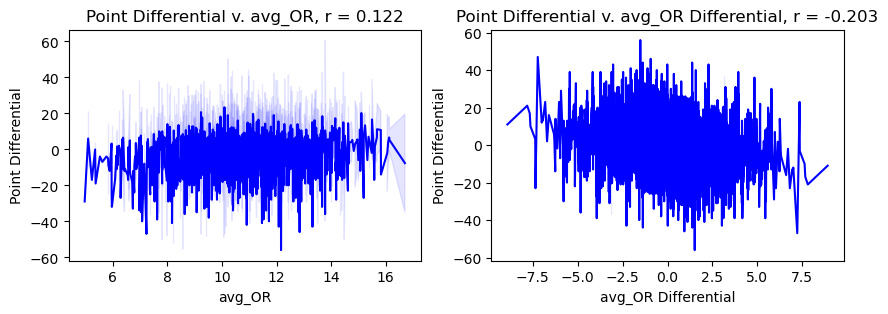

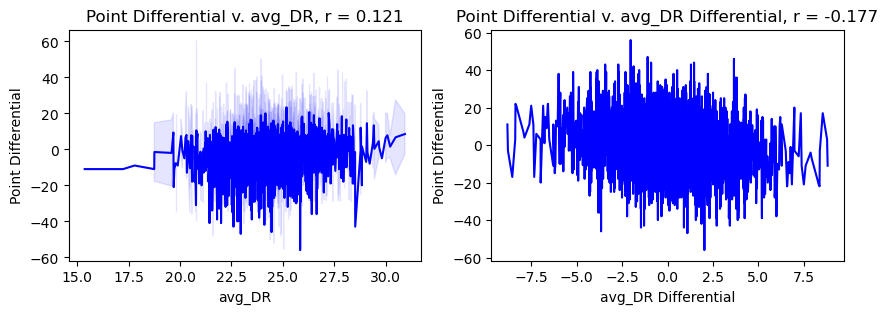

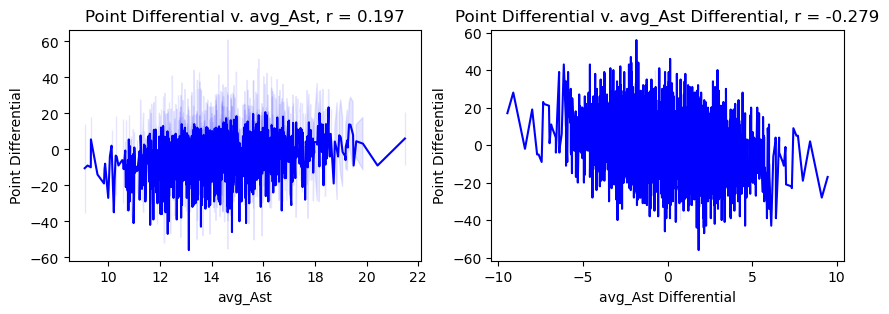

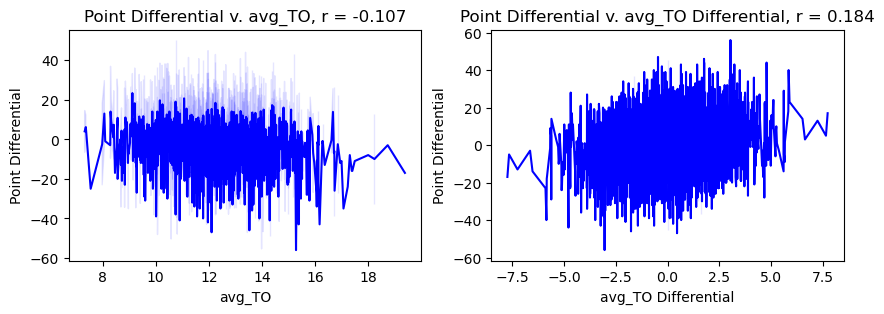

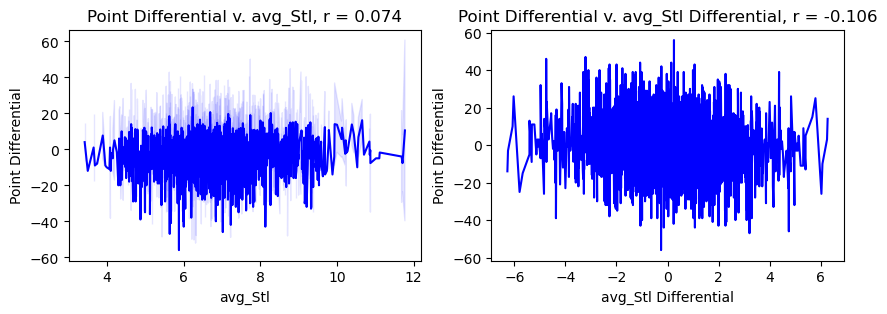

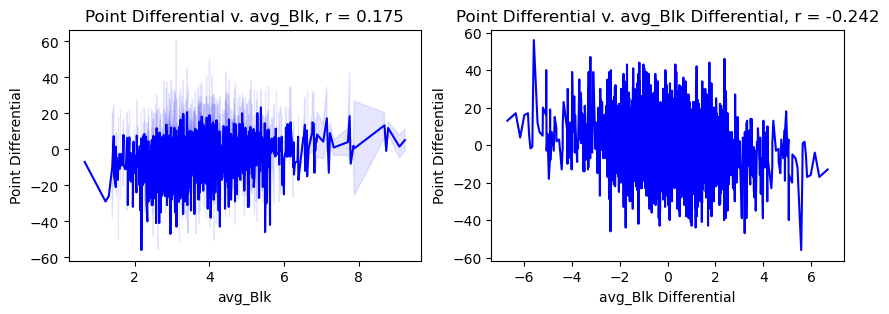

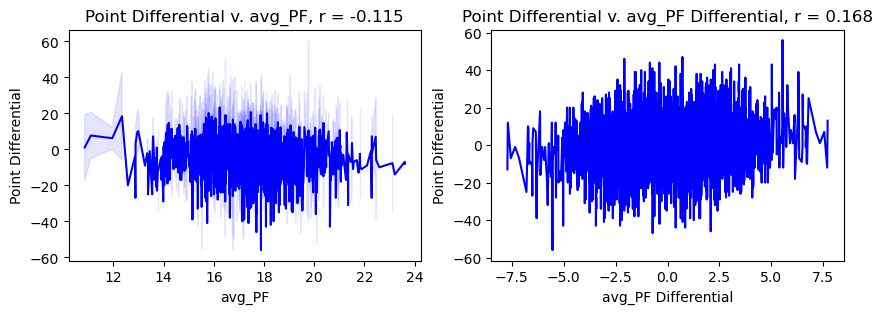

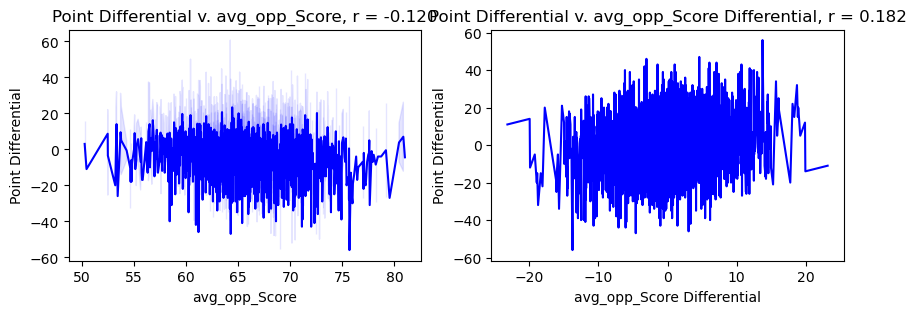

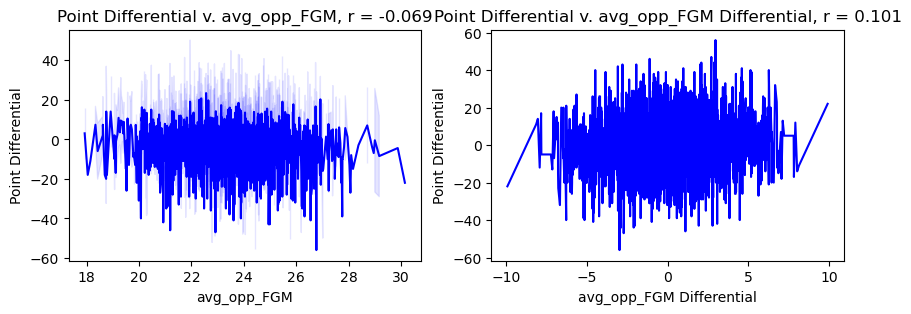

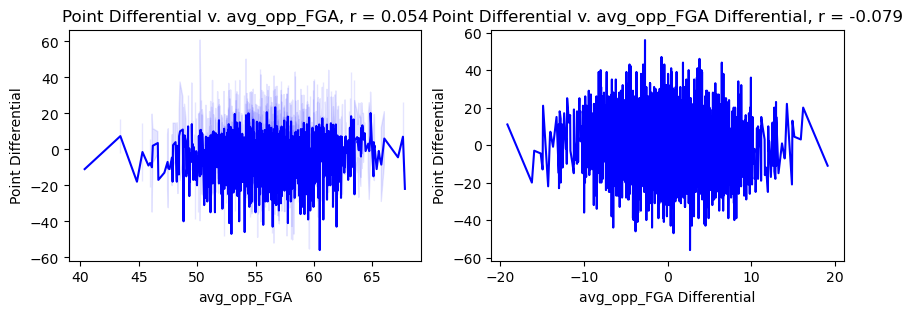

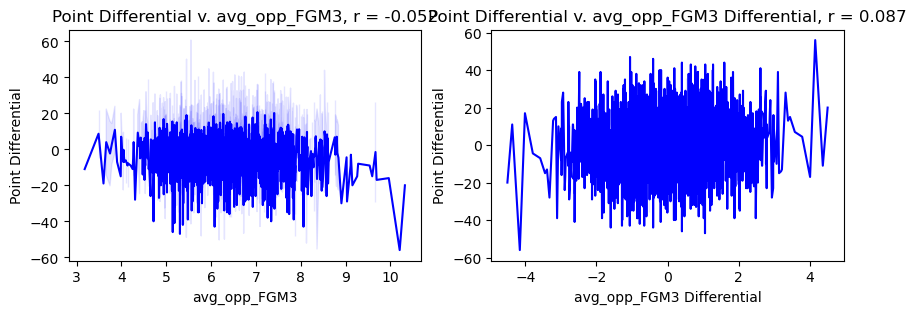

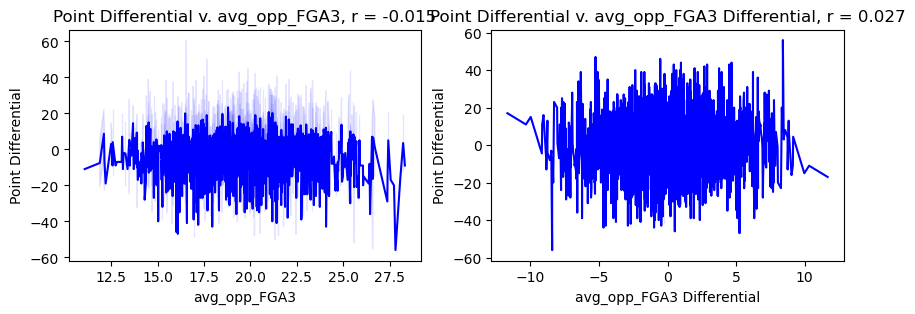

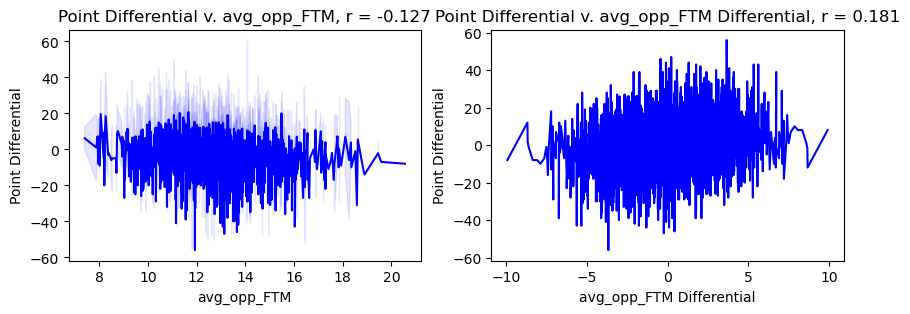

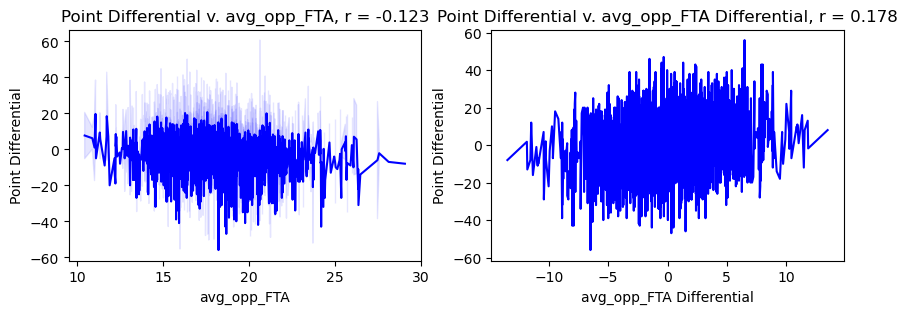

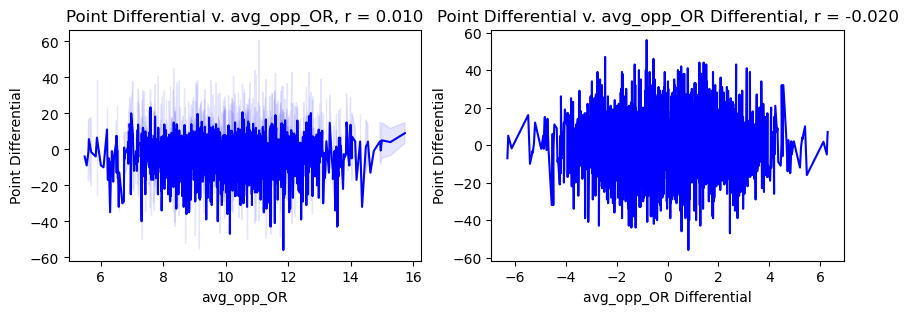

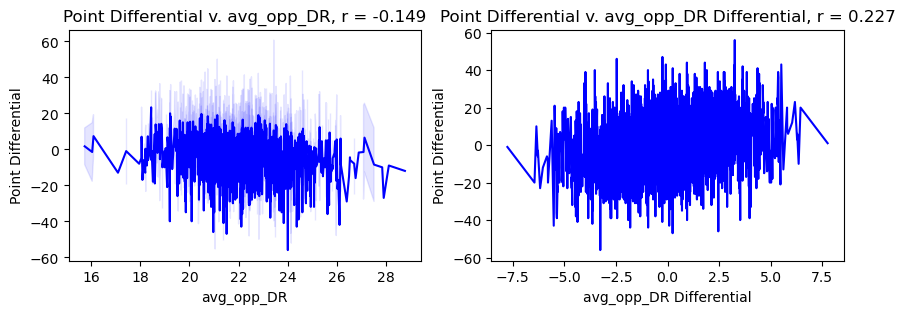

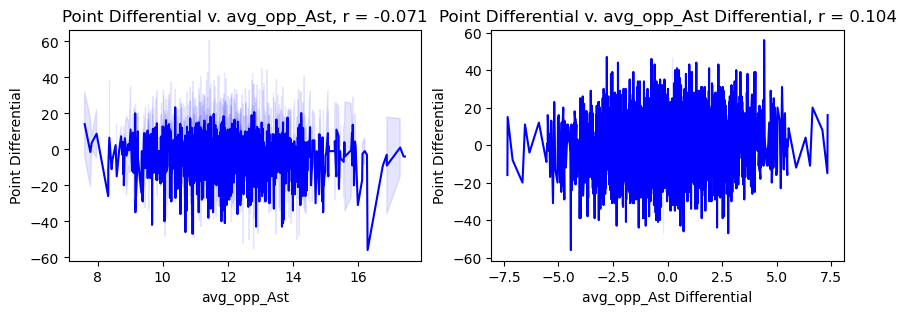

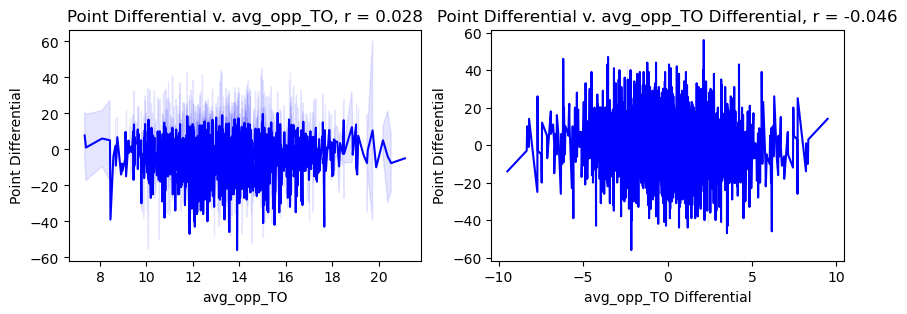

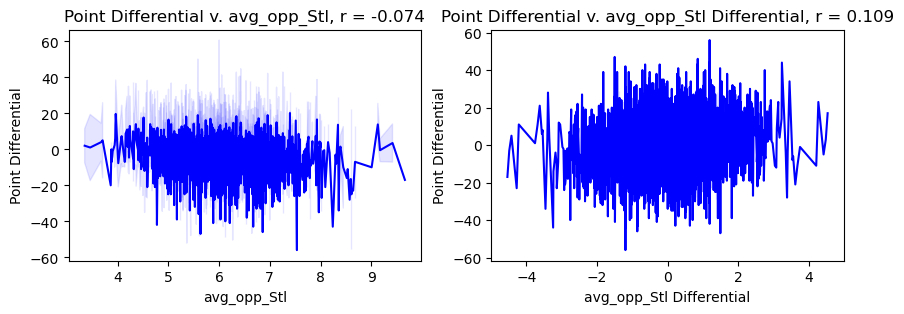

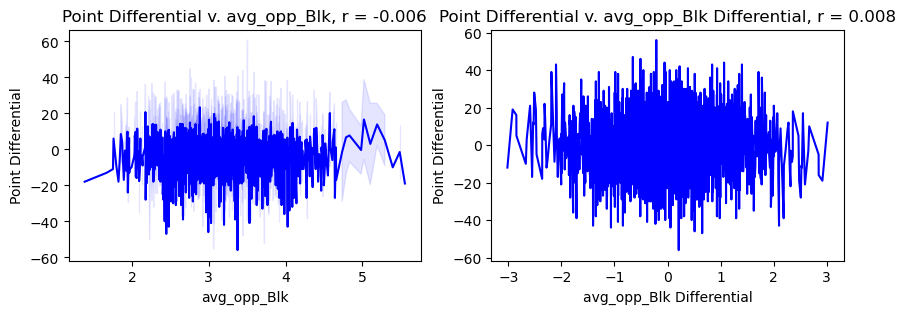

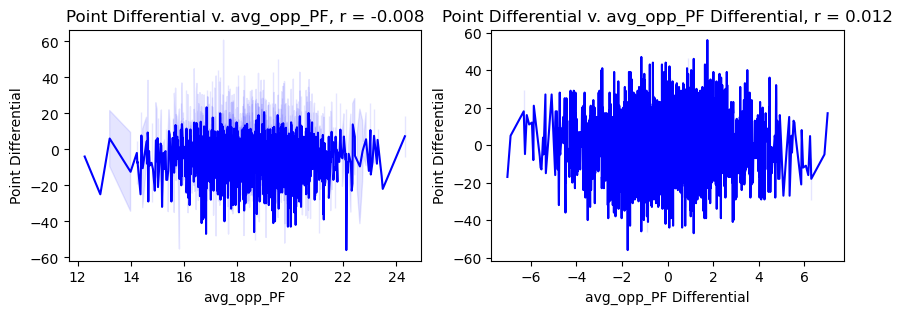

In [32]:
# select a set of stats and view how correlated they are with tournament point differential
my_stats = ["seed", "avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA", 'avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

opponent_stats = [stat[:4] + "opponent_" + stat[4:] for stat in my_stats[2:]]

for statistic in my_stats:
    visualize_stat_correlation(statistic)

for statistic in opponent_stats:
    visualize_stat_correlation(statistic)

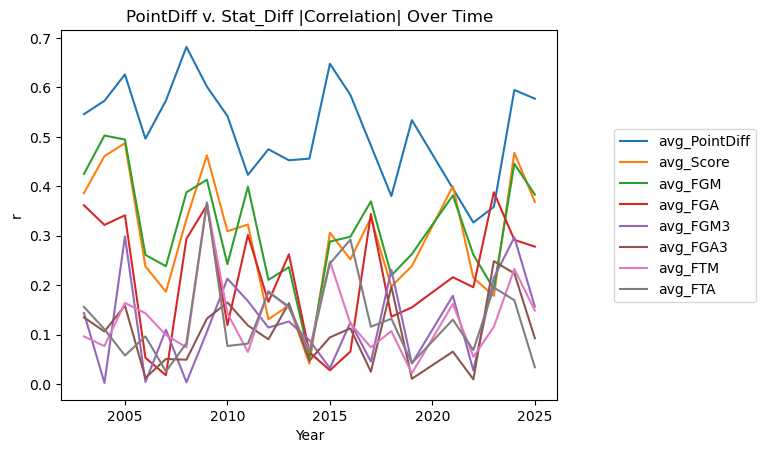

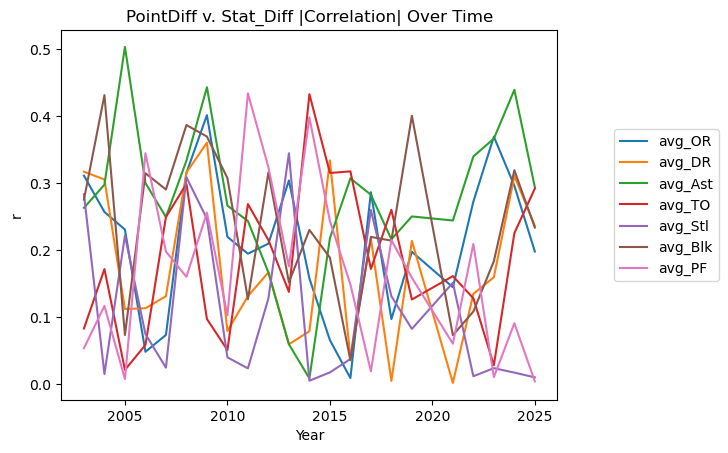

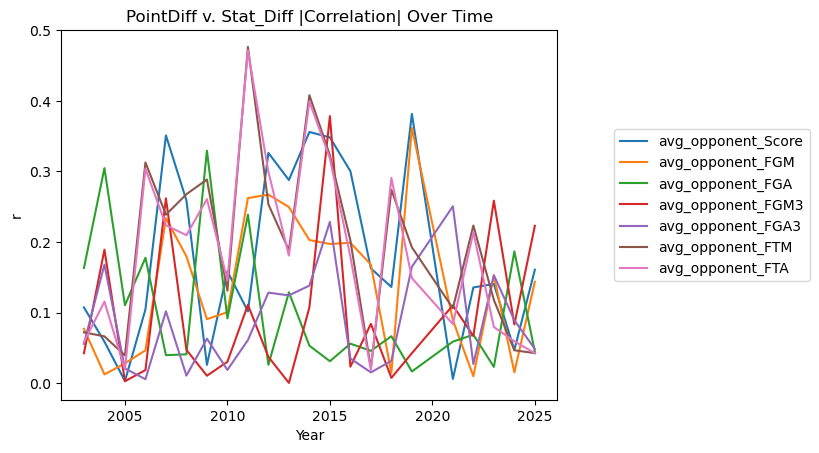

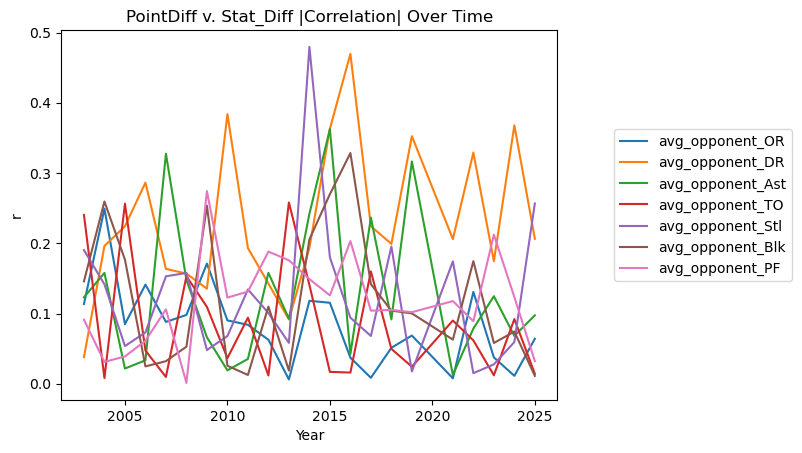

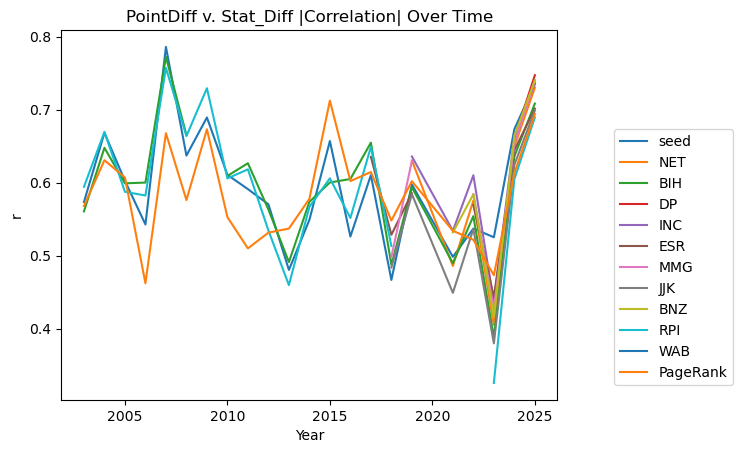

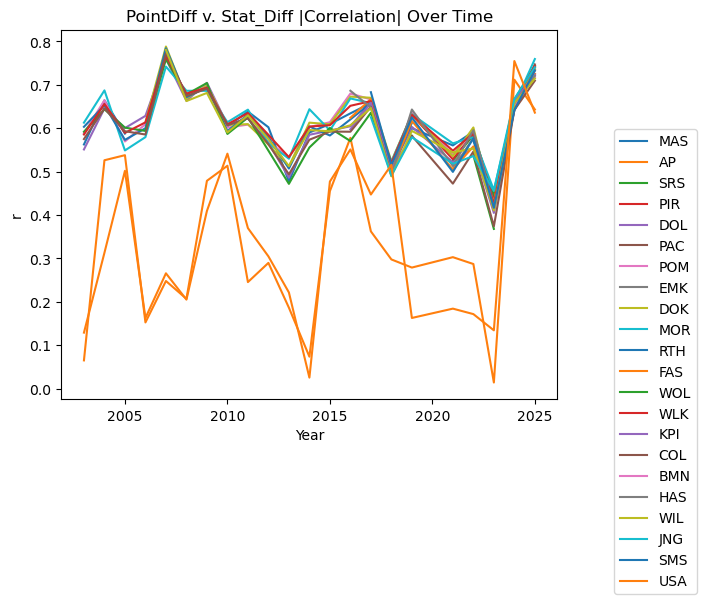

In [33]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation_over_time(stat_list):

    for stat_name in stat_list:

        years = list(range(2003, 2026))
        years.remove(2020)

        r_list = []

        for year in years:

            subset_tourney_data = M_tourney_data.loc[M_tourney_data["Season"] == year].copy()

            subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

            corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
            r_diff = corr_diff_df.corr().iloc[0,1]

            r_list.append(abs(r_diff))

        plt.plot(years, r_list, label = stat_name)
    
    plt.title(f"PointDiff v. Stat_Diff |Correlation| Over Time")
    plt.ylabel("r")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor = (1.1, 0.75))
    plt.show()


score_stats =  ["avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA"]

non_score_stats = ['avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

rank_stats = ['seed'] + active_systems[:10] + ['PageRank']
rank_stats_2 = active_systems[10:]

opp_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in score_stats[1:]]
opp_non_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in non_score_stats]

visualize_stat_correlation_over_time(score_stats)
visualize_stat_correlation_over_time(non_score_stats)
visualize_stat_correlation_over_time(opp_score_stats)
visualize_stat_correlation_over_time(opp_non_score_stats)
visualize_stat_correlation_over_time(rank_stats)
visualize_stat_correlation_over_time(rank_stats_2)

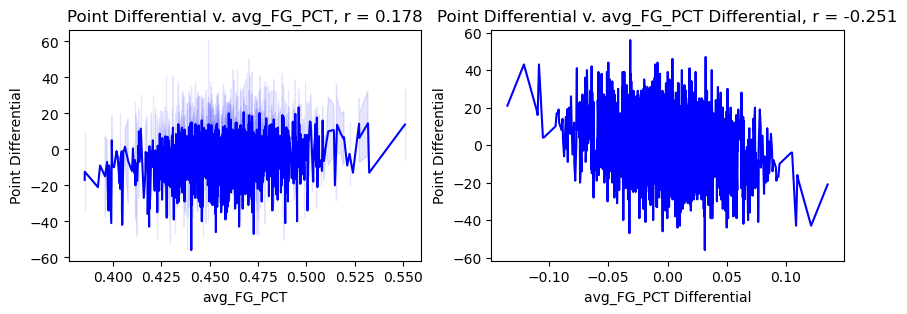

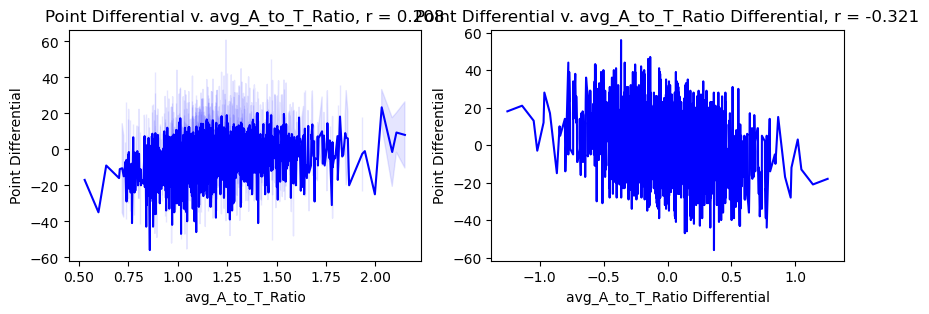

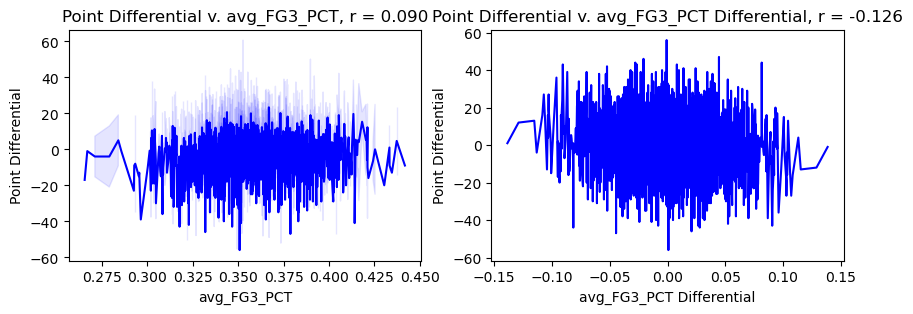

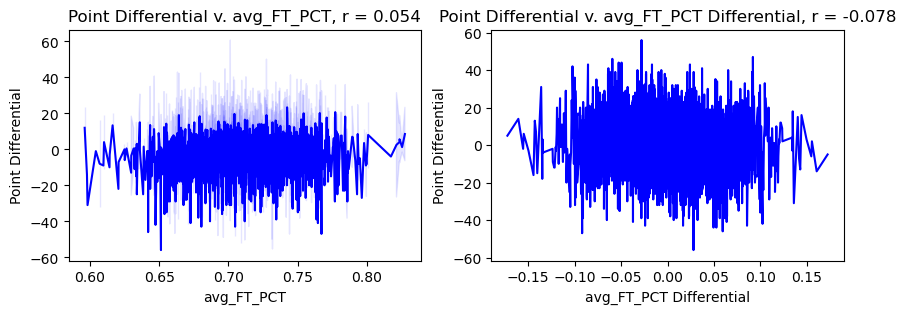

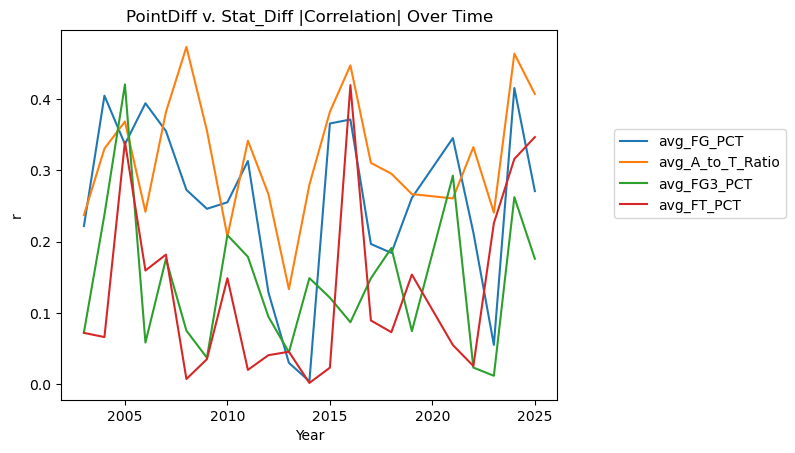

In [34]:
# try some derived metrics
M_tourney_data['T1_avg_FG_PCT'] = M_tourney_data['T1_avg_FGM'] / M_tourney_data['T1_avg_FGA']
M_tourney_data['T2_avg_FG_PCT'] = M_tourney_data['T2_avg_FGM'] / M_tourney_data['T2_avg_FGA']

M_tourney_data['T1_avg_FG3_PCT'] = M_tourney_data['T1_avg_FGM3'] / M_tourney_data['T1_avg_FGA3']
M_tourney_data['T2_avg_FG3_PCT'] = M_tourney_data['T2_avg_FGM3'] / M_tourney_data['T2_avg_FGA3']

M_tourney_data['T1_avg_FT_PCT'] = M_tourney_data['T1_avg_FTM'] / M_tourney_data['T1_avg_FTA']
M_tourney_data['T2_avg_FT_PCT'] = M_tourney_data['T2_avg_FTM'] / M_tourney_data['T2_avg_FTA']

M_tourney_data['T1_avg_A_to_T_Ratio'] = M_tourney_data['T1_avg_Ast'] / M_tourney_data['T1_avg_TO']
M_tourney_data['T2_avg_A_to_T_Ratio'] = M_tourney_data['T2_avg_Ast'] / M_tourney_data['T2_avg_TO']

advanced_stat_list = ['avg_FG_PCT', 'avg_A_to_T_Ratio', 'avg_FG3_PCT', 'avg_FT_PCT']

for advanced_stat in advanced_stat_list:
    visualize_stat_correlation(advanced_stat)

visualize_stat_correlation_over_time(advanced_stat_list)

In [35]:
selected_features = ["T1_seed", 
                     "T2_seed", 
                     "seed_Diff", 
                     "T1_PageRank", "T2_PageRank",
                     "PageRank_Diff",
                     "T1_POM", "T2_POM",
                     "POM_Diff",
                     "T1_BMN", "T2_BMN",
                     "BMN_Diff",
                     "T1_avg_Score", "T2_avg_Score",
                     "T1_avg_Blk", "T2_avg_Blk",
                     "T1_avg_PF", "T2_avg_PF",
                     "T1_avg_FGA", "T2_avg_FGA",
                     "T1_avg_opponent_FGM", "T2_avg_opponent_FGM",
                     "T1_avg_opponent_FGA", "T2_avg_opponent_FGA",
                     "T1_avg_opponent_Blk", "T2_avg_opponent_Blk",
                     "T1_avg_opponent_PF", "T2_avg_opponent_PF",
                     "T1_avg_PointDiff", "T2_avg_PointDiff"
                     ]


print(f"Number of selected features: {len(selected_features)}")

Number of selected features: 30


In [36]:

# Specify hyperparameters for XGBoost

param = {
    "objective": "reg:squarederror",
    "booster" : "gbtree",
    "eta" : 0.01,
    "subsample" : 0.6,
    "colsample_bynode" : 0.8,
    "num_parallel_tree" : 2,
    "min_child_weight" : 4,
    "max_depth" : 4,
    "tree_method" : "hist",
    "grow_policy" : "lossguide",
    "max_bin" : 32
}

num_rounds = 700

In [37]:
# Training with holdout validation - predict one year's results based on all other years

models = {}

mask_mae = []
mask_preds = []
mask_targets = []
mask_ss = []

for mask_season in set(M_tourney_data.Season):
    x_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, selected_features].values
    y_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, "PointDiff"].values

    x_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, selected_features].values
    y_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "PointDiff"].values
    season_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dvalidation = xgb.DMatrix(x_validation, label = y_validation)

    models[mask_season] = xgb.train(
        params = param,
        dtrain = dtrain,
        num_boost_round = num_rounds
    )

    preds = models[mask_season].predict(dvalidation)
    print(f"Mask Season: {mask_season} MAE: {mean_absolute_error(y_validation, preds)}")

    mask_mae.append(mean_absolute_error(y_validation, preds))
    mask_preds += list(preds)
    mask_targets += list(y_validation)
    mask_ss += list(season_validation)

print(f"Average MAE:  {np.mean(mask_mae)}")

# train on each respective year, get predicted outcome, then check against actual to see how much point diff was off

Mask Season: 2003 MAE: 9.113904996839281
Mask Season: 2004 MAE: 7.991518073271598
Mask Season: 2005 MAE: 7.553176356702009
Mask Season: 2006 MAE: 8.705802252945594
Mask Season: 2007 MAE: 7.896781040008257
Mask Season: 2008 MAE: 9.476628023401847
Mask Season: 2009 MAE: 9.386263661089146
Mask Season: 2010 MAE: 8.136069060752117
Mask Season: 2011 MAE: 8.954730556804568
Mask Season: 2012 MAE: 7.727125883503983
Mask Season: 2013 MAE: 10.825792170140529
Mask Season: 2014 MAE: 8.946503659583641
Mask Season: 2015 MAE: 7.695333509471199
Mask Season: 2016 MAE: 9.552986510595922
Mask Season: 2017 MAE: 7.66645358412667
Mask Season: 2018 MAE: 8.821626064319712
Mask Season: 2019 MAE: 9.487706335326331
Mask Season: 2021 MAE: 10.217302277185626
Mask Season: 2022 MAE: 10.052644321342212
Mask Season: 2023 MAE: 9.383353469816113
Mask Season: 2024 MAE: 10.268389298844694
Mask Season: 2025 MAE: 8.564767165863222
Average MAE:  8.928402648724285


<Axes: xlabel='pred_point_diff', ylabel='average_win_pct'>

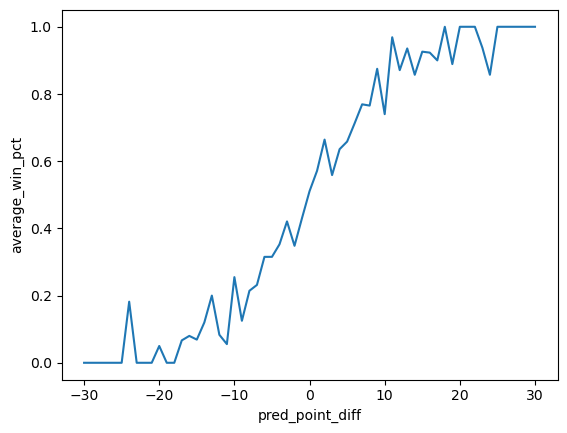

In [38]:
# Plot a graph of average win percentage vs. predicted point differential

df = pd.DataFrame({
    "Season" : mask_ss,
    "pred" : mask_preds,
    "label" : [(t > 0) for t in mask_targets]
})

df["pred_point_diff"] = df["pred"].astype(int)

xdf = df.clip(-30,30).groupby("pred_point_diff")["label"].mean().reset_index(name = "average_win_pct")

seaborn.lineplot(x = xdf["pred_point_diff"], y = xdf["average_win_pct"])

brier: 0.18599554429824974


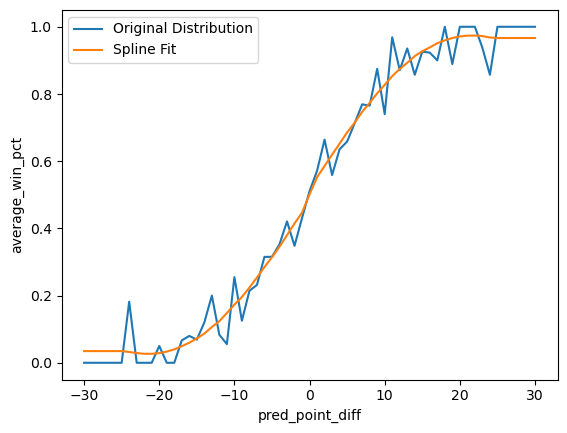

In [39]:
# Fit a Curve to the jagged data derived in the average win percentage vs pred point diff graph

t = 25
dat = list(zip(mask_preds, np.array(mask_targets) > 0))
dat = sorted(dat, key = lambda x:x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k = 5)
spline_fit = np.clip(spline_model(np.clip(mask_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(mask_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_point_diff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.xlabel("pred_point_diff")
plt.ylabel('average_win_pct')
plt.plot(xdf['pred_point_diff'], xdf['label'])
plt.plot(xdf['pred_point_diff'], xdf['spline'])
plt.legend(['Original Distribution', 'Spline Fit'])

In [40]:
# For each season's tournament, compute and display the brier score

avg_brier_score = 0.0
num_seasons = 0

for mask_season in set(M_tourney_data.Season):

    x = df.loc[df["Season"] == mask_season, "spline"].values
    y = df.loc[df["Season"] == mask_season, "label"].values
    print(mask_season, np.round(brier_score_loss(y,x), 5))
    avg_brier_score += brier_score_loss(y,x)
    num_seasons += 1

avg_brier_score /= num_seasons

print("average brier score: ", avg_brier_score)


2003 0.19411
2004 0.17058
2005 0.1668
2006 0.19539
2007 0.15626
2008 0.15207
2009 0.16865
2010 0.19495
2011 0.22371
2012 0.19098
2013 0.20002
2014 0.21042
2015 0.17814
2016 0.18509
2017 0.16923
2018 0.19661
2019 0.16532
2021 0.20098
2022 0.2242
2023 0.20735
2024 0.20059
2025 0.13671
average brier score:  0.1858242528988091


In [41]:
correlation_df

,Stat,r,r_diff
0,PageRank,0.403613,-0.578638
1,NET,-0.379243,0.584590
2,BIH,-0.389401,0.589596
3,DP,-0.440529,0.699244
4,INC,-0.392973,0.604985
...,...,...,...
62,avg_opp_PF,-0.007818,0.012487
63,avg_FG_PCT,0.178485,-0.250598
64,avg_A_to_T_Ratio,0.207805,-0.321002
65,avg_FG3_PCT,0.090203,-0.126132


In [42]:
correlation_df["|r|"] = abs(correlation_df["r"])
correlation_df["|r_diff|"] = abs(correlation_df["r_diff"])
correlation_df

,Stat,r,r_diff,|r|,|r_diff|
0,PageRank,0.403613,-0.578638,0.403613,0.578638
1,NET,-0.379243,0.584590,0.379243,0.584590
2,BIH,-0.389401,0.589596,0.389401,0.589596
3,DP,-0.440529,0.699244,0.440529,0.699244
4,INC,-0.392973,0.604985,0.392973,0.604985
...,...,...,...,...,...
62,avg_opp_PF,-0.007818,0.012487,0.007818,0.012487
63,avg_FG_PCT,0.178485,-0.250598,0.178485,0.250598
64,avg_A_to_T_Ratio,0.207805,-0.321002,0.207805,0.321002
65,avg_FG3_PCT,0.090203,-0.126132,0.090203,0.126132


In [43]:
correlation_df_by_r_diff = correlation_df.sort_values(by=["|r_diff|"], ascending=False)
correlation_df_by_r_diff = correlation_df_by_r_diff.reset_index(drop=True)
correlation_df_by_r_diff

,Stat,r,r_diff,|r|,|r_diff|
0,WAB,-0.461443,0.720312,0.461443,0.720312
1,DP,-0.440529,0.699244,0.440529,0.699244
2,PAC,-0.436872,0.693352,0.436872,0.693352
3,BMN,-0.434045,0.681724,0.434045,0.681724
4,KPI,-0.398713,0.624380,0.398713,0.624380
...,...,...,...,...,...
62,avg_opp_FGA3,-0.015071,0.026792,0.015071,0.026792
63,avg_FTA,0.016865,-0.026339,0.016865,0.026339
64,avg_opp_OR,0.010224,-0.019752,0.010224,0.019752
65,avg_opp_PF,-0.007818,0.012487,0.007818,0.012487


In [44]:
for c in M_tourney_data.columns:
    statistic = c.split('_')
    # 1 - 2
    if len(statistic) >= 2 and statistic[1] == 'avg':
        stat_name = c[3:]
        print(stat_name)
        M_tourney_data[f"{stat_name}_Diff"] = M_tourney_data[f"T1_{stat_name}"] - M_tourney_data[f"T2_{stat_name}"]
    

avg_Score
avg_FGM
avg_FGA
avg_FGM3
avg_FGA3
avg_FTM
avg_FTA
avg_OR
avg_DR
avg_Ast
avg_TO
avg_Stl
avg_Blk
avg_PF
avg_opponent_Score
avg_opponent_FGM
avg_opponent_FGA
avg_opponent_FGM3
avg_opponent_FGA3
avg_opponent_FTM
avg_opponent_FTA
avg_opponent_OR
avg_opponent_DR
avg_opponent_Ast
avg_opponent_TO
avg_opponent_Stl
avg_opponent_Blk
avg_opponent_PF
avg_PointDiff
avg_Score
avg_FGM
avg_FGA
avg_FGM3
avg_FGA3
avg_FTM
avg_FTA
avg_OR
avg_DR
avg_Ast
avg_TO
avg_Stl
avg_Blk
avg_PF
avg_opponent_Score
avg_opponent_FGM
avg_opponent_FGA
avg_opponent_FGM3
avg_opponent_FGA3
avg_opponent_FTM
avg_opponent_FTA
avg_opponent_OR
avg_opponent_DR
avg_opponent_Ast
avg_opponent_TO
avg_opponent_Stl
avg_opponent_Blk
avg_opponent_PF
avg_PointDiff
avg_FG_PCT
avg_FG_PCT
avg_FG3_PCT
avg_FG3_PCT
avg_FT_PCT
avg_FT_PCT
avg_A_to_T_Ratio
avg_A_to_T_Ratio


In [45]:
print(correlation_df_by_r_diff)

            Stat         r    r_diff       |r|  |r_diff|
0            WAB -0.461443  0.720312  0.461443  0.720312
1             DP -0.440529  0.699244  0.440529  0.699244
2            PAC -0.436872  0.693352  0.436872  0.693352
3            BMN -0.434045  0.681724  0.434045  0.681724
4            KPI -0.398713  0.624380  0.398713  0.624380
..           ...       ...       ...       ...       ...
62  avg_opp_FGA3 -0.015071  0.026792  0.015071  0.026792
63       avg_FTA  0.016865 -0.026339  0.016865  0.026339
64    avg_opp_OR  0.010224 -0.019752  0.010224  0.019752
65    avg_opp_PF -0.007818  0.012487  0.007818  0.012487
66   avg_opp_Blk -0.006173  0.008484  0.006173  0.008484

[67 rows x 5 columns]


Number of selected features: 67
Mask Season: 2003 MAE: 8.994173261154597
Mask Season: 2004 MAE: 7.815472419744927
Mask Season: 2005 MAE: 8.014623434767257
Mask Season: 2006 MAE: 8.314564909128887
Mask Season: 2007 MAE: 8.440462699372114
Mask Season: 2008 MAE: 9.558001892699394
Mask Season: 2009 MAE: 9.367733959525099
Mask Season: 2010 MAE: 8.078272629687046
Mask Season: 2011 MAE: 8.71882068190112
Mask Season: 2012 MAE: 7.622781133597368
Mask Season: 2013 MAE: 10.613749607143365
Mask Season: 2014 MAE: 8.383582031255461
Mask Season: 2015 MAE: 7.74602579583675
Mask Season: 2016 MAE: 9.92925825675897
Mask Season: 2017 MAE: 8.207639533164564
Mask Season: 2018 MAE: 8.605458750258235
Mask Season: 2019 MAE: 9.485843019427154
Mask Season: 2021 MAE: 10.28912125158152
Mask Season: 2022 MAE: 9.821026197395861
Mask Season: 2023 MAE: 9.859203183056653
Mask Season: 2024 MAE: 9.931866896463864
Mask Season: 2025 MAE: 8.470160974623639
Average MAE:  8.92126556902472
brier: 0.18671320205358594
2003 0.194

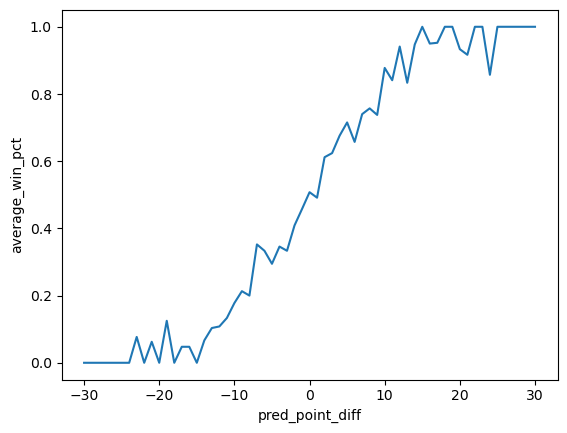

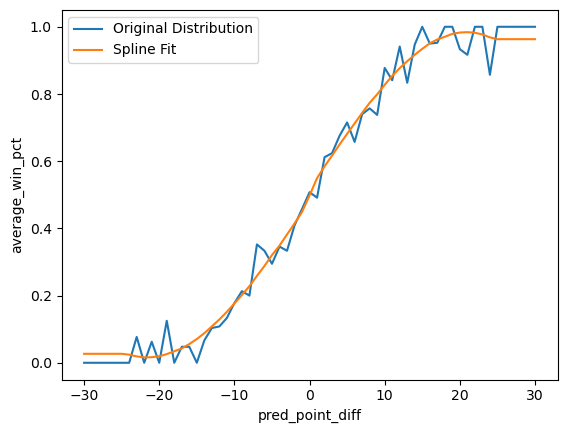

In [48]:
selected_features = [x for x in M_tourney_data.columns if x.endswith("_Diff")]
print(f"Number of selected features: {len(selected_features)}")


# Specify hyperparameters for XGBoost

param = {
    "objective": "reg:squarederror",
    "booster" : "gbtree",
    "eta" : 0.01,
    "subsample" : 0.6,
    "colsample_bynode" : 0.8,
    "num_parallel_tree" : 2,
    "min_child_weight" : 4,
    "max_depth" : 4,
    "tree_method" : "hist",
    "grow_policy" : "lossguide",
    "max_bin" : 32
}

num_rounds = 700

# Training with holdout validation - predict one year's results based on all other years

models = {}

mask_mae = []
mask_preds = []
mask_targets = []
mask_ss = []

for mask_season in set(M_tourney_data.Season):
    x_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, selected_features].values
    y_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, "PointDiff"].values

    x_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, selected_features].values
    y_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "PointDiff"].values
    season_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train, feature_names=selected_features)
    dvalidation = xgb.DMatrix(x_validation, label = y_validation, feature_names=selected_features)

    models[mask_season] = xgb.train(
        params = param,
        dtrain = dtrain,
        num_boost_round = num_rounds
    )

    preds = models[mask_season].predict(dvalidation)
    print(f"Mask Season: {mask_season} MAE: {mean_absolute_error(y_validation, preds)}")

    mask_mae.append(mean_absolute_error(y_validation, preds))
    mask_preds += list(preds)
    mask_targets += list(y_validation)
    mask_ss += list(season_validation)

print(f"Average MAE:  {np.mean(mask_mae)}")

# train on each respective year, get predicted outcome, then check against actual to see how much point diff was off

# Plot a graph of average win percentage vs. predicted point differential

df = pd.DataFrame({
    "Season" : mask_ss,
    "pred" : mask_preds,
    "label" : [(t > 0) for t in mask_targets]
})

df["pred_point_diff"] = df["pred"].astype(int)

xdf = df.clip(-30,30).groupby("pred_point_diff")["label"].mean().reset_index(name = "average_win_pct")

seaborn.lineplot(x = xdf["pred_point_diff"], y = xdf["average_win_pct"])

# Fit a Curve to the jagged data derived in the average win percentage vs pred point diff graph

t = 25
dat = list(zip(mask_preds, np.array(mask_targets) > 0))
dat = sorted(dat, key = lambda x:x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k = 5)
spline_fit = np.clip(spline_model(np.clip(mask_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(mask_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_point_diff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.xlabel("pred_point_diff")
plt.ylabel('average_win_pct')
plt.plot(xdf['pred_point_diff'], xdf['label'])
plt.plot(xdf['pred_point_diff'], xdf['spline'])
plt.legend(['Original Distribution', 'Spline Fit'])

# For each season's tournament, compute and display the brier score

avg_brier_score = 0.0
num_seasons = 0

for mask_season in set(M_tourney_data.Season):

    x = df.loc[df["Season"] == mask_season, "spline"].values
    y = df.loc[df["Season"] == mask_season, "label"].values
    print(mask_season, np.round(brier_score_loss(y,x), 5))
    avg_brier_score += brier_score_loss(y,x)
    num_seasons += 1

avg_brier_score /= num_seasons

print("average brier score: ", avg_brier_score)

/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/xgboost/plotting.py:117: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(1, 1)


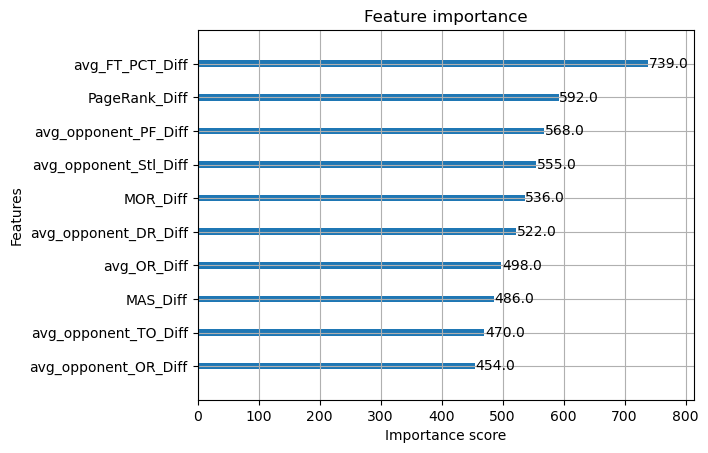

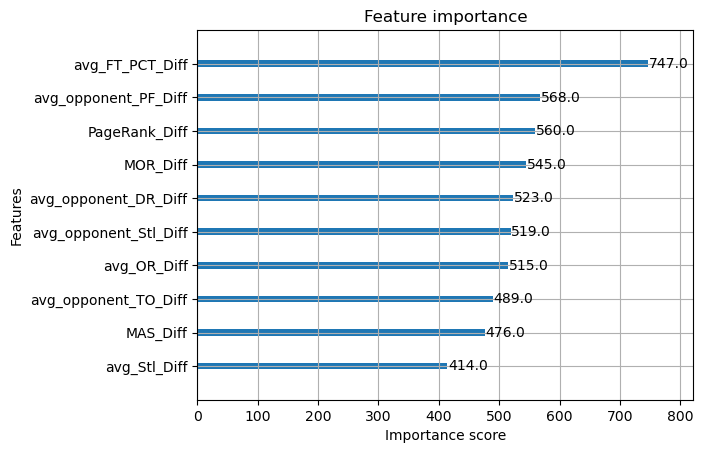

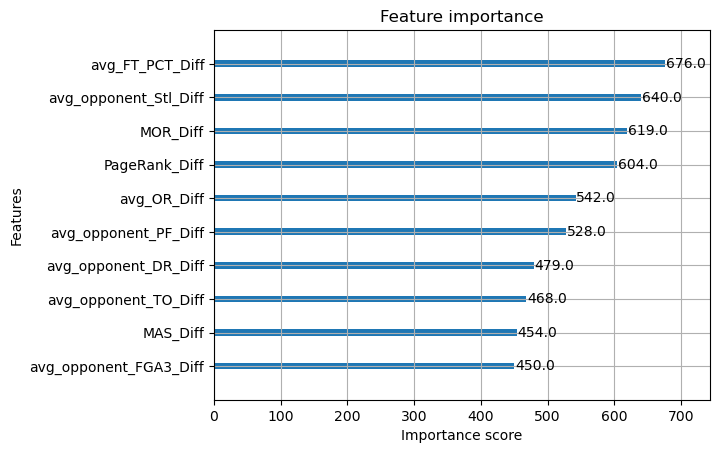

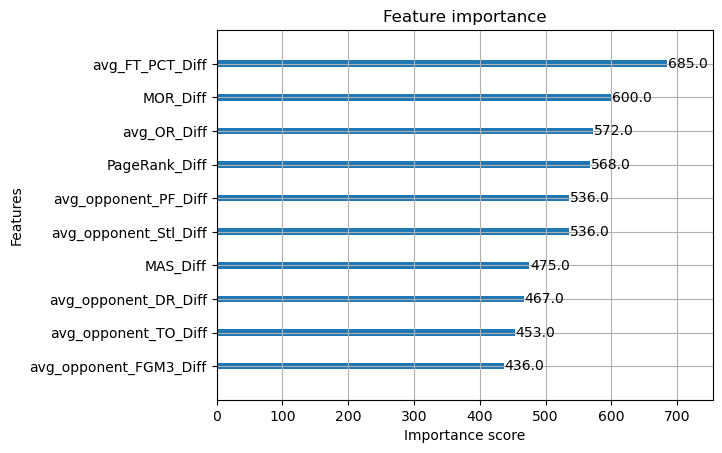

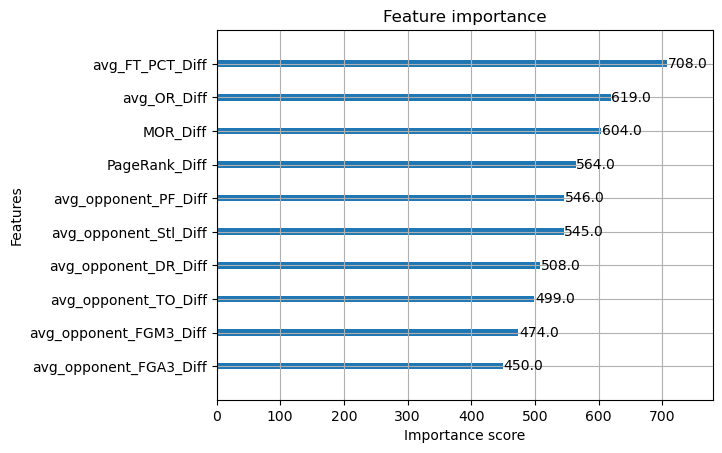

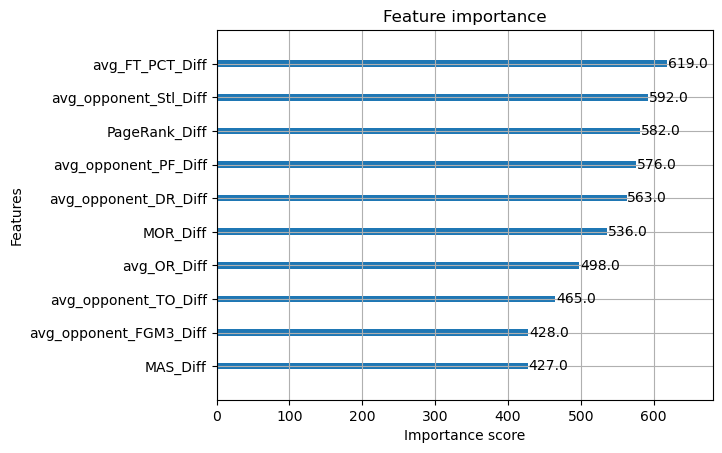

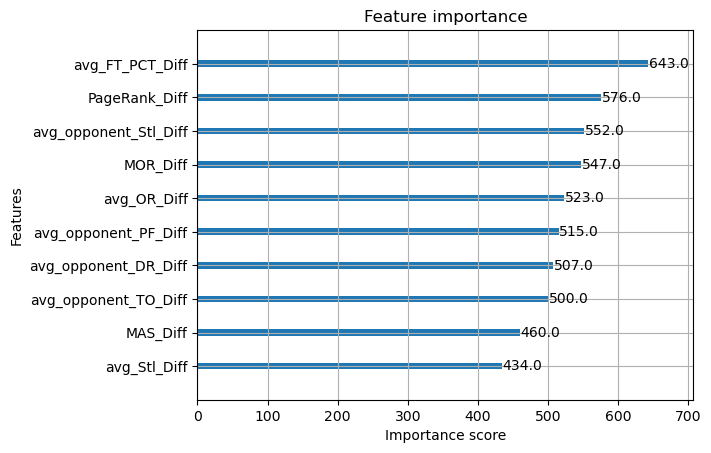

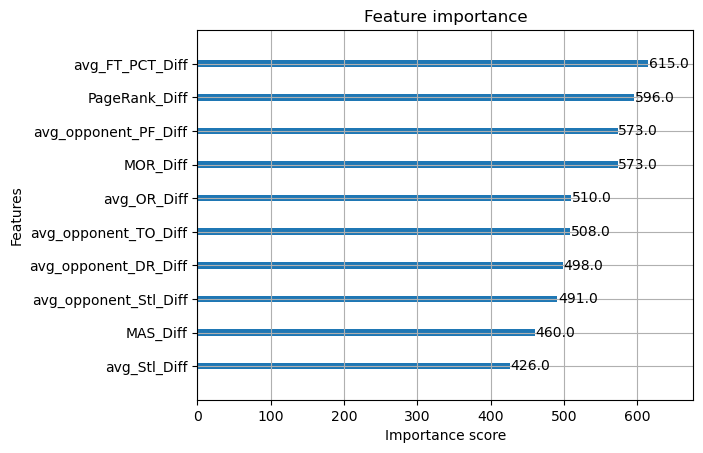

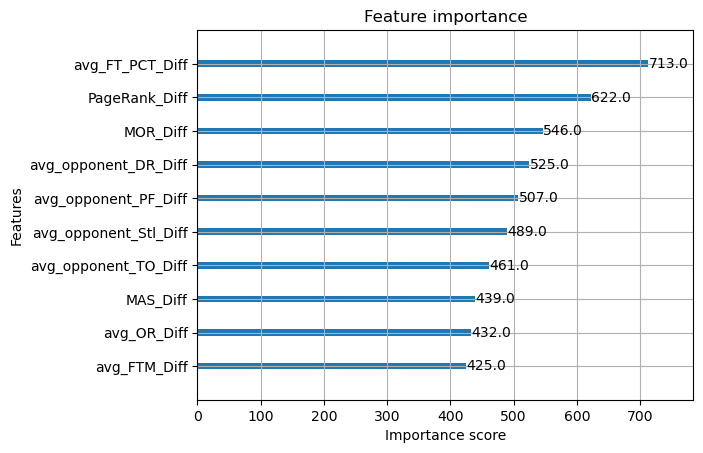

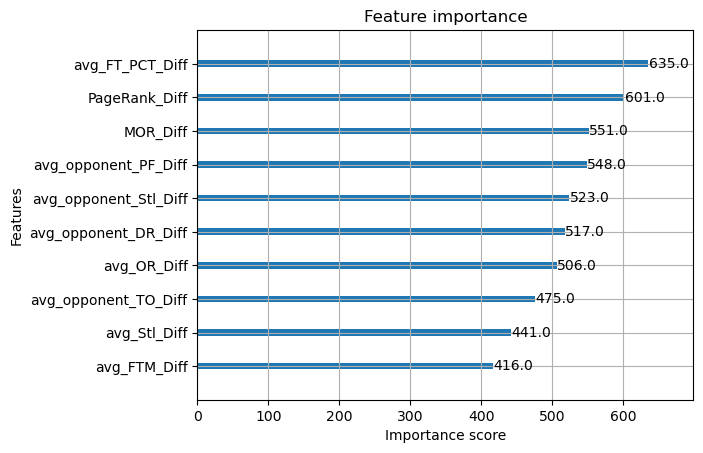

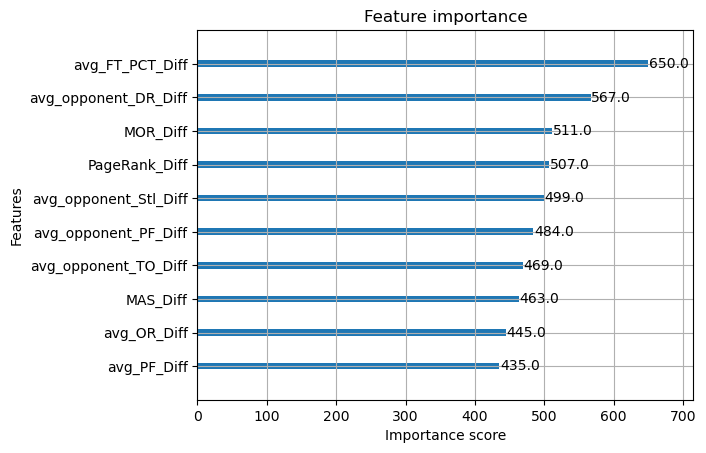

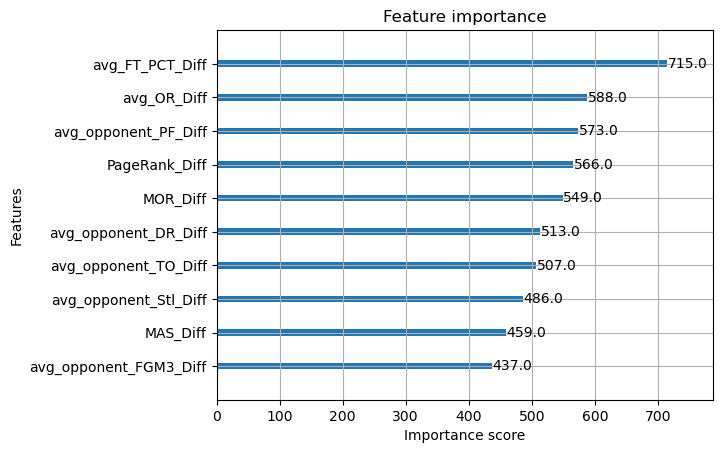

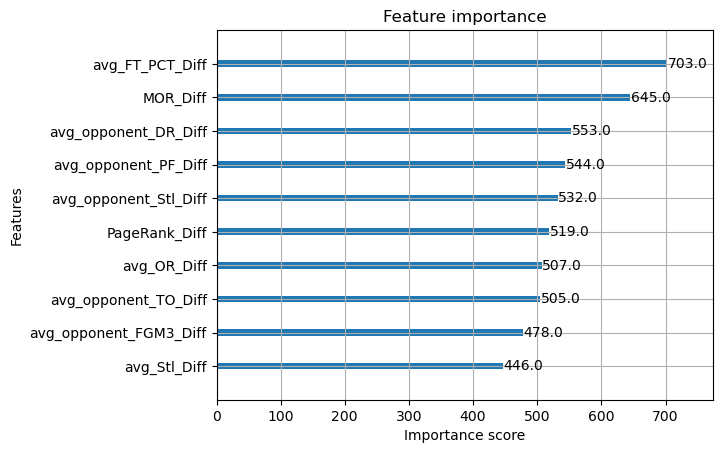

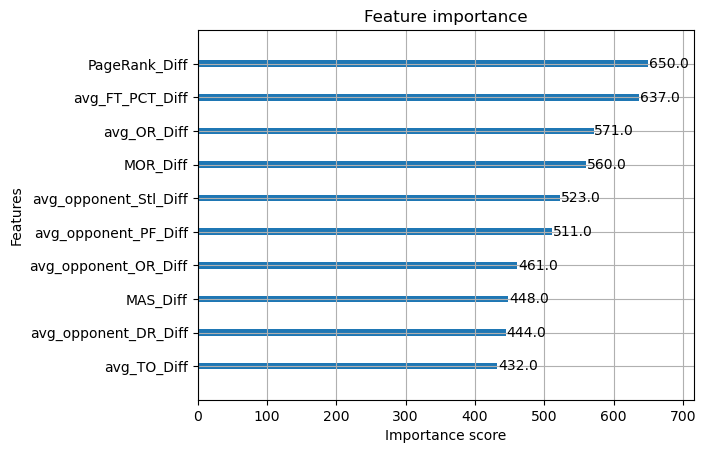

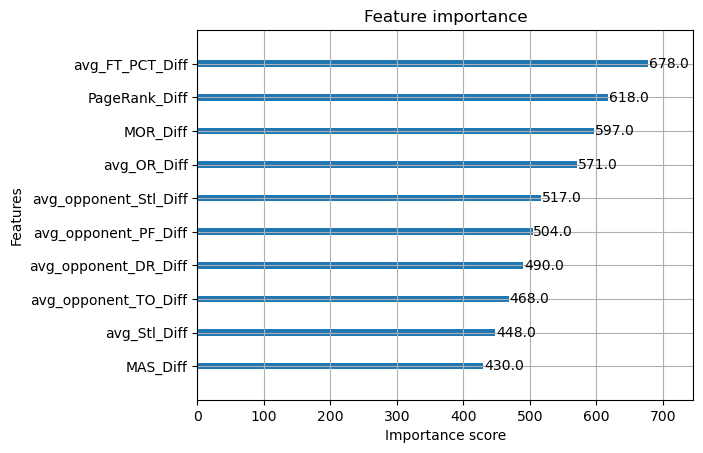

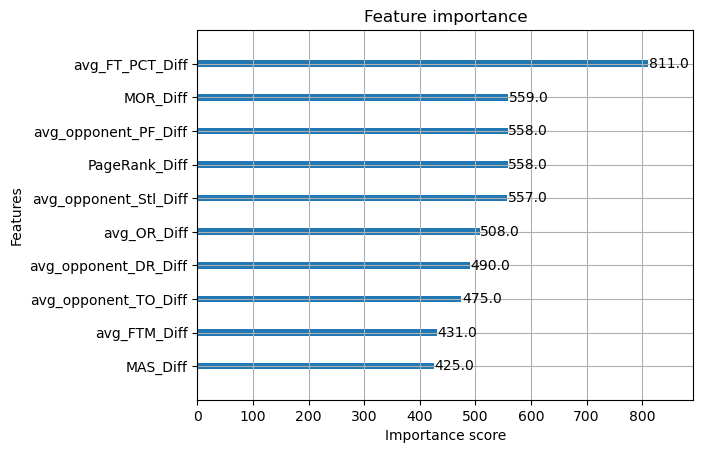

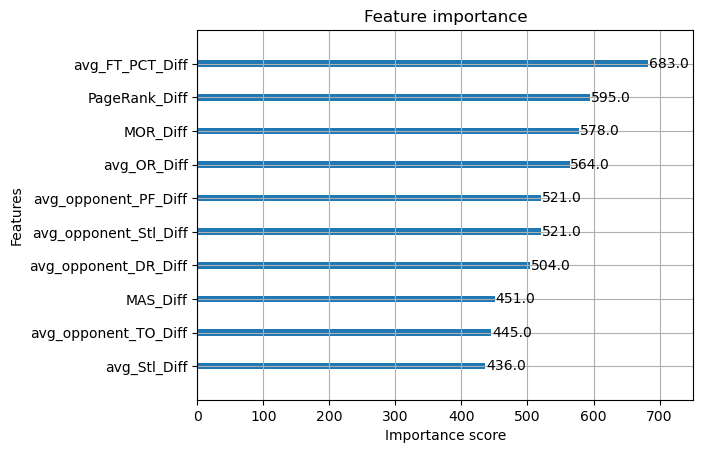

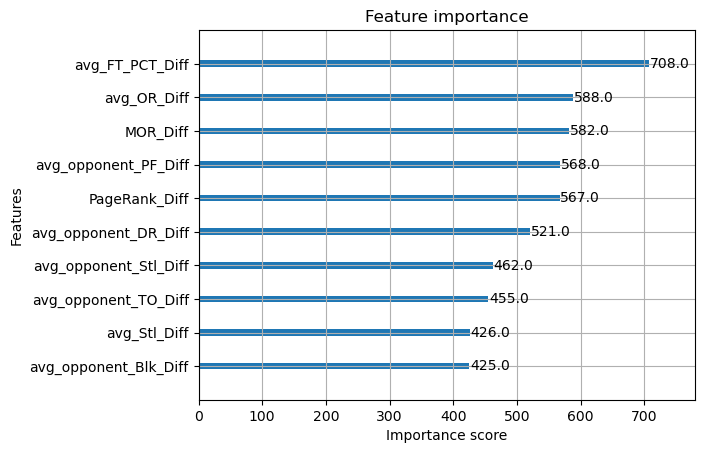

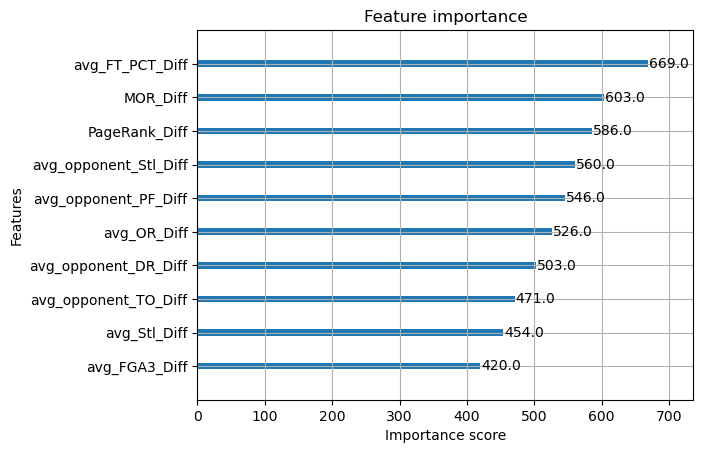

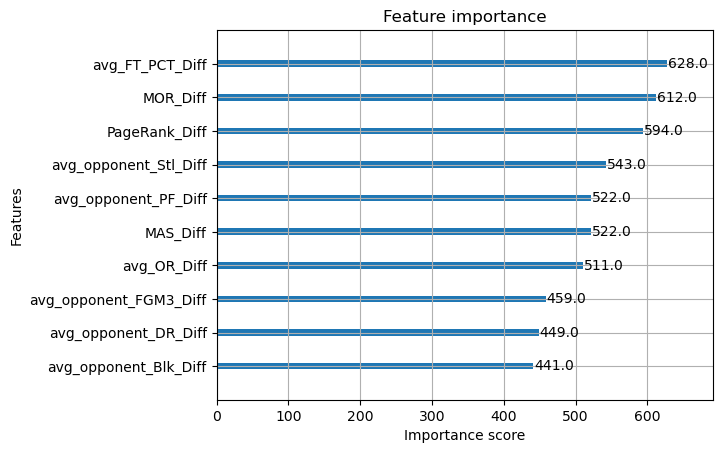

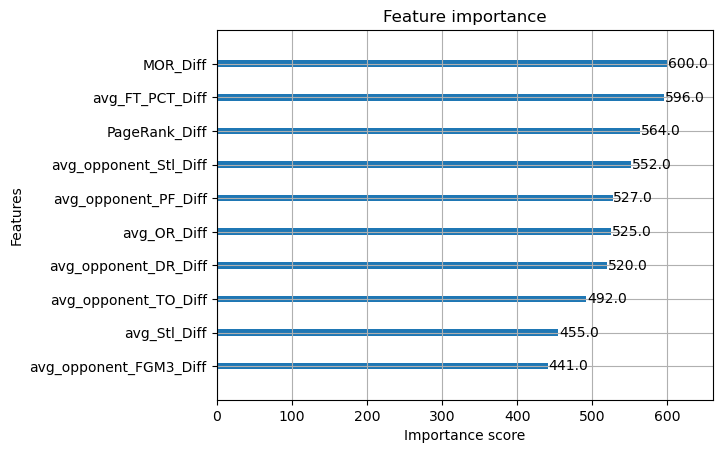

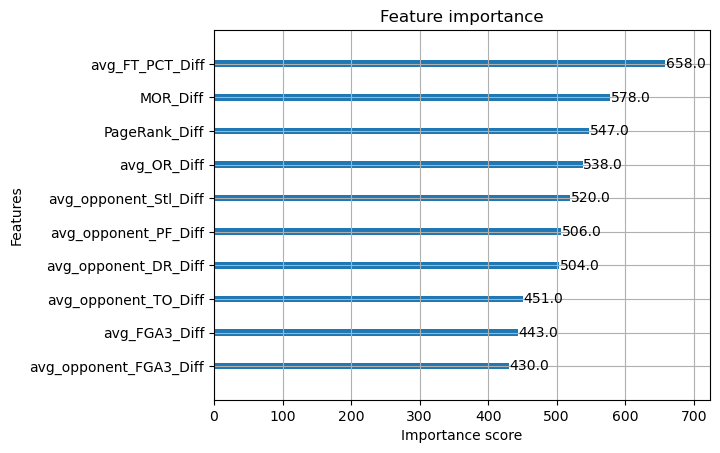

In [49]:
for year in years:
    xgb.plot_importance(models[year], max_num_features=10)

In [ ]:
selected_features = ["seed_Diff", "WAB_Diff", "POM_Diff", ]


# Specify hyperparameters for XGBoost

param = {
    "objective": "reg:squarederror",
    "booster" : "gbtree",
    "eta" : 0.01,
    "subsample" : 0.6,
    "colsample_bynode" : 0.8,
    "num_parallel_tree" : 2,
    "min_child_weight" : 4,
    "max_depth" : 4,
    "tree_method" : "hist",
    "grow_policy" : "lossguide",
    "max_bin" : 32
}

num_rounds = 700

# Training with holdout validation - predict one year's results based on all other years

models = {}

mask_mae = []
mask_preds = []
mask_targets = []
mask_ss = []

for mask_season in set(M_tourney_data.Season):
    x_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, selected_features].values
    y_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, "PointDiff"].values

    x_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, selected_features].values
    y_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "PointDiff"].values
    season_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train, feature_names=selected_features)
    dvalidation = xgb.DMatrix(x_validation, label = y_validation, feature_names=selected_features)

    models[mask_season] = xgb.train(
        params = param,
        dtrain = dtrain,
        num_boost_round = num_rounds
    )

    preds = models[mask_season].predict(dvalidation)
    print(f"Mask Season: {mask_season} MAE: {mean_absolute_error(y_validation, preds)}")

    mask_mae.append(mean_absolute_error(y_validation, preds))
    mask_preds += list(preds)
    mask_targets += list(y_validation)
    mask_ss += list(season_validation)

print(f"Average MAE:  {np.mean(mask_mae)}")

# train on each respective year, get predicted outcome, then check against actual to see how much point diff was off

# Plot a graph of average win percentage vs. predicted point differential

df = pd.DataFrame({
    "Season" : mask_ss,
    "pred" : mask_preds,
    "label" : [(t > 0) for t in mask_targets]
})

df["pred_point_diff"] = df["pred"].astype(int)

xdf = df.clip(-30,30).groupby("pred_point_diff")["label"].mean().reset_index(name = "average_win_pct")

seaborn.lineplot(x = xdf["pred_point_diff"], y = xdf["average_win_pct"])

# Fit a Curve to the jagged data derived in the average win percentage vs pred point diff graph

t = 25
dat = list(zip(mask_preds, np.array(mask_targets) > 0))
dat = sorted(dat, key = lambda x:x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k = 5)
spline_fit = np.clip(spline_model(np.clip(mask_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(mask_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_point_diff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.xlabel("pred_point_diff")
plt.ylabel('average_win_pct')
plt.plot(xdf['pred_point_diff'], xdf['label'])
plt.plot(xdf['pred_point_diff'], xdf['spline'])
plt.legend(['Original Distribution', 'Spline Fit'])

# For each season's tournament, compute and display the brier score

avg_brier_score = 0.0
num_seasons = 0

for mask_season in set(M_tourney_data.Season):

    x = df.loc[df["Season"] == mask_season, "spline"].values
    y = df.loc[df["Season"] == mask_season, "label"].values
    print(mask_season, np.round(brier_score_loss(y,x), 5))
    avg_brier_score += brier_score_loss(y,x)
    num_seasons += 1

avg_brier_score /= num_seasons

print("average brier score: ", avg_brier_score)